# Phase 0 — Project paths and persistent storage

This notebook uses Google Drive as the persistent artifact store.

All model-independent data goes under:

`MyDrive/stablewm_project/`

We keep:
- `data/` for observations, states, and metadata
- `latents/` for model embeddings
- `results/` for metrics
- `figures/` for plots
- `logs/` for debugging output

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, json, sys, time
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/stablewm_project")
DATA_DIR = PROJECT_DIR / "data"
LATENTS_DIR = PROJECT_DIR / "latents"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"
LOGS_DIR = PROJECT_DIR / "logs"

for d in [PROJECT_DIR, DATA_DIR, LATENTS_DIR, RESULTS_DIR, FIGURES_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# SWM cache/storage location
STABLEWM_HOME = Path("/content/drive/MyDrive/stablewm_data")
STABLEWM_HOME.mkdir(parents=True, exist_ok=True)
os.environ["STABLEWM_HOME"] = str(STABLEWM_HOME)

print("PROJECT_DIR:", PROJECT_DIR)
print("STABLEWM_HOME:", os.environ["STABLEWM_HOME"])
print("Python:", sys.version)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/stablewm_project
STABLEWM_HOME: /content/drive/MyDrive/stablewm_data
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


# Phase 1 — Environment Setup and Data Collection

## Phase 1.1 — Install stable-worldmodel and dependencies

We use SWM for the environment and data collection only.

This phase does **not** load LeWM/DINO-WM/PLDM yet. Those are Phase 2+.

If this cell fails on PyPI, we install from source.

In [2]:
import subprocess, sys, os
from pathlib import Path

# System packages for rendering. Safe even if PushT itself does not need all of them.
subprocess.run(
    [
        "apt-get", "update", "-y", "-qq"
    ],
    check=False,
)

subprocess.run(
    [
        "apt-get", "install", "-y", "-qq",
        "libosmesa6-dev", "libgl1-mesa-glx", "libglfw3", "patchelf",
        "libglib2.0-0", "libsm6", "libxext6", "libxrender-dev"
    ],
    check=False,
)

os.environ["MUJOCO_GL"] = "osmesa"

# First try PyPI. If it fails, fallback to source.
try:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "stable-worldmodel", "numpy", "tqdm", "pymunk", "pygame"],
        check=True,
    )
    print("Installed stable-worldmodel from PyPI.")
except subprocess.CalledProcessError:
    print("PyPI install failed. Installing from source.")
    if not Path("/content/stable-worldmodel").exists():
        subprocess.run(
            ["git", "clone", "https://github.com/galilai-group/stable-worldmodel.git", "/content/stable-worldmodel"],
            check=True,
        )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", "/content/stable-worldmodel", "pymunk", "pygame"],
        check=True,
    )
    print("Installed stable-worldmodel from source.")

import stable_worldmodel as swm
print("Imported stable_worldmodel:", swm)

Installed stable-worldmodel from PyPI.
Imported stable_worldmodel: <module 'stable_worldmodel' from '/usr/local/lib/python3.12/dist-packages/stable_worldmodel/__init__.py'>


## Phase 1.2 — Inspect the SWM World API in this runtime

SWM is under active development, so we inspect the installed version instead of assuming a Gym-style API.

Important expectation:
- `World` may not expose `.step()`
- rollouts are likely driven by `World._run(...)`, `World.collect(...)`, or `World.evaluate(...)`
- observations and state are stored in `world.infos`

In [3]:
import inspect
import stable_worldmodel as swm

print("World signature:")
print(inspect.signature(swm.World))

print("\nWorld public attributes/methods:")
print([a for a in dir(swm.World) if not a.startswith("_")])

print("\nWorld private run-related methods:")
print([a for a in dir(swm.World) if "run" in a.lower() or "iter" in a.lower()])

# Save source for debugging/Gemini/teammates
world_src_path = LOGS_DIR / "swm_world_source.txt"
with open(world_src_path, "w") as f:
    f.write(inspect.getsource(swm.World))

print("\nSaved World source to:", world_src_path)

World signature:
(env_name: str, num_envs: int, image_shape: tuple[int, int], goal_transform: collections.abc.Callable[[typing.Any], typing.Any] | None = None, image_transform: collections.abc.Callable[[typing.Any], typing.Any] | None = None, seed: int = 2349867, history_size: int = 1, frame_skip: int = 1, max_episode_steps: int = 100, verbose: int = 1, extra_wrappers: list[collections.abc.Callable] | None = None, goal_conditioned: bool = True, **kwargs: Any) -> None

World public attributes/methods:
['action_space', 'close', 'evaluate', 'evaluate_from_dataset', 'num_envs', 'observation_space', 'record_dataset', 'record_video', 'reset', 'set_policy', 'single_action_space', 'single_observation_space', 'single_variation_space', 'step', 'variation_space']

World private run-related methods:
[]

Saved World source to: /content/drive/MyDrive/stablewm_project/logs/swm_world_source.txt


## Phase 1.3 — Create PushT world and inspect reset state

This cell creates the PushT environment.

We use `image_shape=(224, 224)` because the LeWM config we inspected uses 224×224 images.

We do not assume `reset()` returns anything. Instead, we inspect `world.infos`.

In [4]:
import stable_worldmodel as swm
import numpy as np

def make_pusht_world(num_envs=1, image_shape=(224, 224), max_episode_steps=100):
    return swm.World(
        "swm/PushT-v1",
        num_envs=num_envs,
        image_shape=image_shape,
        max_episode_steps=max_episode_steps,
    )

world = make_pusht_world(num_envs=1)

reset_out = world.reset(seed=0)
print("reset() returned:", reset_out)
print("world has infos:", hasattr(world, "infos"))

if hasattr(world, "infos"):
    print("info keys:", list(world.infos.keys()))
    for k, v in world.infos.items():
        try:
            print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))
        except Exception as e:
            print(k, type(v), "could not summarize:", e)

2026-05-02 17:37:52.764 | INFO     | stable_worldmodel.world:__init__:123 - 🌍🌍🌍 World swm/PushT-v1 initialized 🌍🌍🌍
2026-05-02 17:37:52.765 | INFO     | stable_worldmodel.world:__init__:125 - 🕹️ 🕹️ 🕹️ Action space 🕹️ 🕹️ 🕹️
2026-05-02 17:37:52.766 | INFO     | stable_worldmodel.world:__init__:126 - Box(-1.0, 1.0, (1, 2), float32)
2026-05-02 17:37:52.767 | INFO     | stable_worldmodel.world:__init__:128 - 👁️ 👁️ 👁️ Observation space 👁️ 👁️ 👁️
2026-05-02 17:37:52.768 | INFO     | stable_worldmodel.world:__init__:129 - Dict('proprio': Box(0.0, 512.0, (1, 4), float64), 'state': Box(0.0, [[512.         512.         512.         512.           6.28318531
  512.         512.        ]], (1, 7), float64))
2026-05-02 17:37:52.769 | INFO     | stable_worldmodel.world:__init__:132 - ⚗️ ⚗️ ⚗️ Variation space ⚗️ ⚗️ ⚗️


agent:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(8)
    start_position: Box(50.0, 450.0, (2,), float64)
    velocity: Box(0.0, 512.0, (2,), float64)
background:
    color: Box(0, 255, (3,), uint8)
block:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(7, start=1)
    start_position: Box(100.0, 400.0, (2,), float64)
goal:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    position: Box(50.0, 450.0, (2,), float64)
    scale: Box(20.0, 60.0, (), float32)
rendering:
    render_goal: Discrete(2)

reset() returned: None
world has infos: True
info keys: ['env_name', '_env_name', 'pos_agent', '_pos_agent', 'vel_agent', '_vel_agent', 'block_pose', '_block_pose', 'goal_pose', '_goal_pose', 'goal_state', '_goal_state', 'goal_proprio', '_goal_proprio', 'n_contacts', '_n_contacts', 'goal', '_goal', 'render_time', '_render_time', 'pixels', '_pixels', 'proprio', '_proprio', 'state', '_state', 'reward', '_reward', 'terminated', '_terminated', 'truncated', '_truncated', 'action', '_action', 'step_idx', '_step_idx', 'id', '_id']
env_name <class 'numpy.ndarray'> (1,) object
_env_name <class 'numpy.ndarray'> (1,) bool
pos_agent <class 'numpy.ndarray'> (1, 1, 2) float64
_pos_agent <class 'numpy.ndarray'> (1,) bool
vel_agent <class 'numpy.ndarray'> (1, 1, 2) float64
_vel_agent <class 'numpy.ndarray'> (1,) bool
block_pose <class 'numpy.ndarray'> (1, 1, 3) float64
_block_pose <class 'numpy.ndarray'> (1,) bool
goal_pose <class 'numpy.ndarray'> (1, 1, 3) float64
_goal_pose <class 'numpy.ndarray'> (

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


## Phase 1.4 — Define a minimal SWM-compatible random policy

SWM policies need:
- `set_env(env)`
- `get_action(obs, **kwargs)`

The world passes `world.infos` into `get_action`.

This policy is only for collecting random rollout data.

In [5]:
try:
    from stable_worldmodel.policy import BasePolicy
except Exception:
    BasePolicy = object

class RandomPolicy(BasePolicy):
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        self.env = None
        self.num_envs = None
        self.action_space = None

    def set_env(self, env):
        self.env = env
        self.num_envs = getattr(env, "num_envs", None)

        # Prefer the vectorized action space from the world.
        self.action_space = getattr(env, "action_space", None)
        if self.action_space is None and hasattr(env, "single_action_space"):
            self.action_space = env.single_action_space

    def get_action(self, obs, **kwargs):
        # Return a sample from the vectorized action space.
        if self.action_space is not None:
            return self.action_space.sample()

        # Fallback if action_space is missing
        if isinstance(obs, dict) and "pixels" in obs:
            n = len(obs["pixels"])
        elif self.num_envs is not None:
            n = self.num_envs
        else:
            n = 1

        return self.rng.uniform(-1.0, 1.0, size=(n, 2)).astype(np.float32)


## Phase 1.5 — Smoke-test rollout through SWM's internal runner

Since this SWM version has no public `world.step()`, we use `world._run(...)`.

The callback collects a few observations/states from `world.infos`.

If this fails, inspect `logs/swm_world_source.txt` and the printed method signatures.

In [6]:
from collections import defaultdict
import numpy as np

world = make_pusht_world(num_envs=2)
policy = RandomPolicy(seed=0)
world.set_policy(policy)

print("Has step:", hasattr(world, "step"))

smoke = defaultdict(list)

def smoke_on_step(w):
    keys = list(w.infos.keys())
    if len(smoke["keys"]) == 0:
        smoke["keys"].append(keys)
        print("First callback info keys:", keys)

    # Squeeze the singleton history dimension
    if "pixels" in w.infos:
        smoke["pixels"].append(np.asarray(w.infos["pixels"])[:, 0].copy())

    # Save any likely state-like keys for inspection.
    for key in ["state", "states", "observation", "observations", "proprio", "achieved_goal", "desired_goal"]:
        if key in w.infos:
            smoke[key].append(np.asarray(w.infos[key])[:, 0].copy())

# Run only a few steps.
world.reset(seed=0)
for _ in range(5):
    world.step() # Policy is called internally by SWM
    smoke_on_step(world)

print("Collected smoke keys:", list(smoke.keys()))
for k, vals in smoke.items():
    if k == "keys":
        continue
    arr = np.asarray(vals)
    print(k, "->", arr.shape, arr.dtype)

world.close()


2026-05-02 17:37:52.901 | INFO     | stable_worldmodel.world:__init__:123 - 🌍🌍🌍 World swm/PushT-v1 initialized 🌍🌍🌍
2026-05-02 17:37:52.902 | INFO     | stable_worldmodel.world:__init__:125 - 🕹️ 🕹️ 🕹️ Action space 🕹️ 🕹️ 🕹️
2026-05-02 17:37:52.903 | INFO     | stable_worldmodel.world:__init__:126 - Box(-1.0, 1.0, (2, 2), float32)
2026-05-02 17:37:52.904 | INFO     | stable_worldmodel.world:__init__:128 - 👁️ 👁️ 👁️ Observation space 👁️ 👁️ 👁️
2026-05-02 17:37:52.906 | INFO     | stable_worldmodel.world:__init__:129 - Dict('proprio': Box(0.0, 512.0, (2, 4), float64), 'state': Box(0.0, [[512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         512.         512.           6.28318531
  512.         512.        ]], (2, 7), float64))
2026-05-02 17:37:52.906 | INFO     | stable_worldmodel.world:__init__:132 - ⚗️ ⚗️ ⚗️ Variation space ⚗️ ⚗️ ⚗️


agent:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(8)
    start_position: Box(50.0, 450.0, (2,), float64)
    velocity: Box(0.0, 512.0, (2,), float64)
background:
    color: Box(0, 255, (3,), uint8)
block:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(7, start=1)
    start_position: Box(100.0, 400.0, (2,), float64)
goal:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    position: Box(50.0, 450.0, (2,), float64)
    scale: Box(20.0, 60.0, (), float32)
rendering:
    render_goal: Discrete(2)

/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Has step: True
First callback info keys: ['env_name', '_env_name', 'pos_agent', '_pos_agent', 'vel_agent', '_vel_agent', 'block_pose', '_block_pose', 'goal_pose', '_goal_pose', 'goal_state', '_goal_state', 'goal_proprio', '_goal_proprio', 'n_contacts', '_n_contacts', 'goal', '_goal', 'render_time', '_render_time', 'pixels', '_pixels', 'proprio', '_proprio', 'state', '_state', 'reward', '_reward', 'terminated', '_terminated', 'truncated', '_truncated', 'action', '_action', 'step_idx', '_step_idx', 'id', '_id']
Collected smoke keys: ['keys', 'pixels', 'state', 'proprio']
pixels -> (5, 2, 224, 224, 3) uint8
state -> (5, 2, 7) float64
proprio -> (5, 2, 4) float64


## Phase 1.6 — Decide which keys represent pixels and state

We need:
- `pixels`: image observations
- `state`: ground-truth task-relevant state, if available

This cell chooses `pixels` automatically and tries to identify the best state key.

If no clean state key exists, we still save observations now and revisit state extraction.

In [7]:
# Hardcode the confirmed keys
PIXEL_KEY = "pixels"
STATE_KEY = "state"

print("PIXEL_KEY:", PIXEL_KEY)
print("STATE_KEY:", STATE_KEY)


PIXEL_KEY: pixels
STATE_KEY: state


## Phase 1.7 — Collect and save canonical PushT random-rollout dataset

This creates the shared model-independent dataset.

Recommended first run:
- `NUM_ENVS = 8`
- `MAX_STEPS = 100`
- collect about 800 frames

You can scale later.

Saved files:
- `data/pusht_obs.npy`
- `data/pusht_states.npy` if a state key exists
- `data/pusht_metadata.json`

In [8]:
from tqdm.auto import tqdm
import numpy as np
import json, time

NUM_ENVS = 8
MAX_STEPS = 100
SEED = 42

world = make_pusht_world(num_envs=NUM_ENVS, image_shape=(224, 224), max_episode_steps=MAX_STEPS)
world.set_policy(RandomPolicy(seed=SEED))

PIXEL_KEY = "pixels"
STATE_KEY = "state"

obs_chunks = []
state_chunks = []

step_counter = {"t": 0}

def collect_on_step(w):
    step_counter["t"] += 1

    # Squeeze out the singleton history dimension [:, 0, ...]
    if PIXEL_KEY in w.infos:
        obs_chunks.append(np.asarray(w.infos[PIXEL_KEY])[:, 0].copy())

    if STATE_KEY in w.infos:
        state_chunks.append(np.asarray(w.infos[STATE_KEY])[:, 0].copy())

world.reset(seed=SEED)
for _ in tqdm(range(MAX_STEPS), desc="Collecting data"):
    world.step() # Policy is called internally
    collect_on_step(world)
world.close()

# Shape before flattening: (T, num_envs, H, W, C)
obs_raw = np.asarray(obs_chunks)
print("obs_raw:", obs_raw.shape, obs_raw.dtype)

# Flatten env/time into one sample dimension: (T*num_envs, H, W, C)
obs = obs_raw.reshape(-1, *obs_raw.shape[2:])

states = None
if len(state_chunks) > 0:
    states_raw = np.asarray(state_chunks)
    print("states_raw:", states_raw.shape, states_raw.dtype)
    states = states_raw.reshape(-1, *states_raw.shape[2:])

print("obs flattened:", obs.shape, obs.dtype)
if states is not None:
    print("states flattened:", states.shape, states.dtype)
else:
    print("No states saved because STATE_KEY was None or absent.")

np.save(DATA_DIR / "pusht_obs.npy", obs)

if states is not None:
    np.save(DATA_DIR / "pusht_states.npy", states)

metadata = {
    "phase": "phase_1_random_rollout_dataset",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "env_id": "swm/PushT-v1",
    "image_shape": [224, 224],
    "num_envs": NUM_ENVS,
    "max_steps": MAX_STEPS,
    "seed": SEED,
    "pixel_key": PIXEL_KEY,
    "state_key": STATE_KEY,
    "obs_shape": list(obs.shape),
    "obs_dtype": str(obs.dtype),
    "states_shape": list(states.shape) if states is not None else None,
    "stablewm_home": str(STABLEWM_HOME),
}

with open(DATA_DIR / "pusht_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(" -", DATA_DIR / "pusht_obs.npy")
if states is not None:
    print(" -", DATA_DIR / "pusht_states.npy")
print(" -", DATA_DIR / "pusht_metadata.json")


2026-05-02 17:37:53.045 | INFO     | stable_worldmodel.world:__init__:123 - 🌍🌍🌍 World swm/PushT-v1 initialized 🌍🌍🌍
2026-05-02 17:37:53.046 | INFO     | stable_worldmodel.world:__init__:125 - 🕹️ 🕹️ 🕹️ Action space 🕹️ 🕹️ 🕹️
2026-05-02 17:37:53.046 | INFO     | stable_worldmodel.world:__init__:126 - Box(-1.0, 1.0, (8, 2), float32)
2026-05-02 17:37:53.047 | INFO     | stable_worldmodel.world:__init__:128 - 👁️ 👁️ 👁️ Observation space 👁️ 👁️ 👁️
2026-05-02 17:37:53.048 | INFO     | stable_worldmodel.world:__init__:129 - Dict('proprio': Box(0.0, 512.0, (8, 4), float64), 'state': Box(0.0, [[512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         51

agent:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(8)
    start_position: Box(50.0, 450.0, (2,), float64)
    velocity: Box(0.0, 512.0, (2,), float64)
background:
    color: Box(0, 255, (3,), uint8)
block:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(7, start=1)
    start_position: Box(100.0, 400.0, (2,), float64)
goal:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    position: Box(50.0, 450.0, (2,), float64)
    scale: Box(20.0, 60.0, (), float32)
rendering:
    render_goal: Discrete(2)

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


obs_raw: (100, 8, 224, 224, 3) uint8
states_raw: (100, 8, 7) float64
obs flattened: (800, 224, 224, 3) uint8
states flattened: (800, 7) float64
Saved:
 - /content/drive/MyDrive/stablewm_project/data/pusht_obs.npy
 - /content/drive/MyDrive/stablewm_project/data/pusht_states.npy
 - /content/drive/MyDrive/stablewm_project/data/pusht_metadata.json


## Phase 1.8 — Validate saved dataset

Reload from Drive and inspect shapes.

This is the checkpoint for Phase 1.
Do not proceed to encoding until this cell looks correct.

In [9]:
obs_loaded = np.load(DATA_DIR / "pusht_obs.npy")
print("obs_loaded:", obs_loaded.shape, obs_loaded.dtype, obs_loaded.min(), obs_loaded.max())

states_path = DATA_DIR / "pusht_states.npy"
if states_path.exists():
    states_loaded = np.load(states_path)
    print("states_loaded:", states_loaded.shape, states_loaded.dtype)
    print("first state:", states_loaded[0])
else:
    print("No states file exists.")

with open(DATA_DIR / "pusht_metadata.json") as f:
    metadata_loaded = json.load(f)

metadata_loaded

obs_loaded: (800, 224, 224, 3) uint8 65 255
states_loaded: (800, 7) float64
first state: [ 297.11359494   83.59371201  268.82044006  356.61757713    4.20496296
  192.90606689 -270.1100769 ]


{'phase': 'phase_1_random_rollout_dataset',
 'created_at': '2026-05-02 17:37:58',
 'env_id': 'swm/PushT-v1',
 'image_shape': [224, 224],
 'num_envs': 8,
 'max_steps': 100,
 'seed': 42,
 'pixel_key': 'pixels',
 'state_key': 'state',
 'obs_shape': [800, 224, 224, 3],
 'obs_dtype': 'uint8',
 'states_shape': [800, 7],
 'stablewm_home': '/content/drive/MyDrive/stablewm_data'}

# Phase 2 — LeWM encoding (principled)

We load the actual LeWM architecture from the official repo and apply HF weights.

We extract latents using:

    model.encode(batch)["emb"]

This matches the training pipeline exactly.

In [10]:
from huggingface_hub import hf_hub_download

LEWM_REPO = "quentinll/lewm-pusht"

weights_path = hf_hub_download(repo_id=LEWM_REPO, filename="weights.pt")
config_path = hf_hub_download(repo_id=LEWM_REPO, filename="config.json")

print("weights_path:", weights_path)
print("config_path:", config_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


weights.pt:   0%|          | 0.00/72.3M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

weights_path: /root/.cache/huggingface/hub/models--quentinll--lewm-pusht/snapshots/22b330c28c27ead4bfd1888615af1340e3fe9052/weights.pt
config_path: /root/.cache/huggingface/hub/models--quentinll--lewm-pusht/snapshots/22b330c28c27ead4bfd1888615af1340e3fe9052/config.json


In [11]:
!git clone https://github.com/lucas-maes/le-wm.git
%cd le-wm

Cloning into 'le-wm'...
remote: Enumerating objects: 43, done.
remote: Total 43 (delta 0), reused 0 (delta 0), pack-reused 43 (from 1)
Receiving objects: 100% (43/43), 5.27 MiB | 31.73 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/le-wm


In [12]:
import torch
import json

from jepa import JEPA
from module import ARPredictor, Embedder, MLP

In [13]:
from transformers import ViTConfig, ViTModel

def vit_hf(size, patch_size, image_size, pretrained=False, use_mask_token=False):
    if size == "tiny":
        hidden_size = 192
        num_heads = 3
        num_layers = 12
        mlp_dim = 768
    else:
        raise ValueError(f"Unknown size: {size}")

    config = ViTConfig(
        image_size=image_size,
        patch_size=patch_size,
        num_channels=3,
        hidden_size=hidden_size,
        num_hidden_layers=num_layers,
        num_attention_heads=num_heads,
        intermediate_size=mlp_dim,
    )

    return ViTModel(config, add_pooling_layer=False)

In [14]:
with open(config_path) as f:
    cfg = json.load(f)

encoder = vit_hf(
    cfg["encoder"]["size"],
    patch_size=cfg["encoder"]["patch_size"],
    image_size=cfg["encoder"]["image_size"],
)

def build_mlp(k):
    return MLP(
        input_dim=cfg[k]["input_dim"],
        output_dim=cfg[k]["output_dim"],
        hidden_dim=cfg[k]["hidden_dim"],
        norm_fn=torch.nn.BatchNorm1d,
    )

def filter_hydra(d):
    return {k: v for k, v in d.items() if not k.startswith("_")}

model = JEPA(
    encoder=encoder,
    predictor=ARPredictor(**filter_hydra(cfg["predictor"])),
    action_encoder=Embedder(**filter_hydra(cfg["action_encoder"])),
    projector=build_mlp("projector"),
    pred_proj=build_mlp("pred_proj"),
)


In [15]:
state = torch.load(weights_path, map_location="cpu")
model.load_state_dict(state, strict=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(DEVICE).eval()

print("Model loaded successfully.")

Model loaded successfully.


In [16]:
obs = np.load(DATA_DIR / "pusht_obs.npy")

batch = obs[:4]

x = torch.tensor(batch, dtype=torch.float32, device=DEVICE) / 255.0
x = x.permute(0, 3, 1, 2).unsqueeze(1) # Add time dimension: (B, 1, C, H, W)

batch_dict = {"pixels": x}

with torch.no_grad():
    out = model.encode(batch_dict)

# Squeeze the time dimension to get (B, 192)
z = out["emb"].squeeze(1)

print("z shape:", z.shape)
print("mean/std:", z.mean().item(), z.std().item())


z shape: torch.Size([4, 192])
mean/std: -0.04806196317076683 0.903952419757843


In [17]:
from tqdm.auto import tqdm

BATCH_SIZE = 64
zs = []

for i in tqdm(range(0, len(obs), BATCH_SIZE)):
    batch = obs[i:i+BATCH_SIZE]

    x = torch.tensor(batch, dtype=torch.float32, device=DEVICE) / 255.0
    x = x.permute(0, 3, 1, 2).unsqueeze(1) # Add time dimension: (B, 1, C, H, W)

    with torch.no_grad():
        out = model.encode({"pixels": x})
        # Squeeze the time dimension to get (B, 192)
        z = out["emb"].squeeze(1)

    zs.append(z.cpu().numpy())

lewm_z = np.concatenate(zs, axis=0)

np.save(LATENTS_DIR / "lewm_z.npy", lewm_z)

print("Saved:", lewm_z.shape)


  0%|          | 0/13 [00:00<?, ?it/s]

Saved: (800, 192)


# Phase 3 — DINO-WM-style encoding

DINO-WM uses pretrained DINOv2 patch features as its visual representation.

For this phase we encode the same Phase 1 observations using DINOv2 and save two representations:

1. `dinowm_tokens.npy`
   - shape `(N, num_patches, D)`
   - preserves patch-token geometry

2. `dinowm_z.npy`
   - shape `(N, D)`
   - mean-pooled token representation for distance-based comparisons

This is not the DINO-WM predictor. It is the frozen feature representation DINO-WM is built on.

In [18]:
!pip install -q transformers accelerate

## Phase 3.1 — Load DINOv2 encoder

We use Hugging Face `facebook/dinov2-base`.

This gives patch-level visual features. For 224×224 images with patch size 14,
we expect 16×16 = 256 patch tokens, each 768-dimensional.

In [19]:
import torch
import numpy as np
import json, time
from transformers import AutoImageProcessor, Dinov2Model
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DINO_REPO = "facebook/dinov2-base"

processor = AutoImageProcessor.from_pretrained(DINO_REPO)
dino = Dinov2Model.from_pretrained(DINO_REPO).to(DEVICE).eval()

print("Loaded:", DINO_REPO)
print("DEVICE:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loaded: facebook/dinov2-base
DEVICE: cuda


## Phase 3.2 — Smoke test DINOv2 features

DINOv2 returns:
- CLS token
- patch tokens

For DINO-WM-style spatial features, we use patch tokens:

`last_hidden_state[:, 1:, :]`

Expected shape for batch size 4:

`(4, 256, 768)`

In [20]:
obs = np.load(DATA_DIR / "pusht_obs.npy")
print("obs:", obs.shape, obs.dtype, obs.min(), obs.max())

batch = obs[:4]

inputs = processor(images=list(batch), return_tensors="pt").to(DEVICE)

with torch.no_grad():
    out = dino(**inputs)

patch_tokens = out.last_hidden_state[:, 1:, :]
pooled = patch_tokens.mean(dim=1)

print("last_hidden_state:", out.last_hidden_state.shape)
print("patch_tokens:", patch_tokens.shape)
print("pooled:", pooled.shape)
print("pooled mean/std:", pooled.mean().item(), pooled.std().item())

obs: (800, 224, 224, 3) uint8 65 255
last_hidden_state: torch.Size([4, 257, 768])
patch_tokens: torch.Size([4, 256, 768])
pooled: torch.Size([4, 768])
pooled mean/std: -0.03325038030743599 1.2162554264068604


## Phase 3.3 — Encode all observations with DINOv2

We save:
- full patch tokens: `(N, 256, 768)`
- mean-pooled vector: `(N, 768)`

The pooled vector is what we will use for first-pass distance comparisons.
The patch tokens remain available for later spatial analyses.

In [21]:
BATCH_SIZE = 32

all_tokens = []
all_pooled = []

for i in tqdm(range(0, len(obs), BATCH_SIZE), desc="Encoding DINOv2"):
    batch = obs[i:i+BATCH_SIZE]

    inputs = processor(images=list(batch), return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        out = dino(**inputs)
        tokens = out.last_hidden_state[:, 1:, :]   # patch tokens only
        pooled = tokens.mean(dim=1)

    all_tokens.append(tokens.cpu().float().numpy())
    all_pooled.append(pooled.cpu().float().numpy())

dinowm_tokens = np.concatenate(all_tokens, axis=0)
dinowm_z = np.concatenate(all_pooled, axis=0)

print("dinowm_tokens:", dinowm_tokens.shape, dinowm_tokens.dtype)
print("dinowm_z:", dinowm_z.shape, dinowm_z.dtype)
print("dinowm_z mean/std:", dinowm_z.mean(), dinowm_z.std())

np.save(LATENTS_DIR / "dinowm_tokens.npy", dinowm_tokens)
np.save(LATENTS_DIR / "dinowm_z.npy", dinowm_z)

info = {
    "phase": "phase_3_dinowm_style_dinov2_encoding",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "model_repo": DINO_REPO,
    "input_obs": str(DATA_DIR / "pusht_obs.npy"),
    "output_tokens": str(LATENTS_DIR / "dinowm_tokens.npy"),
    "output_pooled": str(LATENTS_DIR / "dinowm_z.npy"),
    "obs_shape": list(obs.shape),
    "tokens_shape": list(dinowm_tokens.shape),
    "pooled_shape": list(dinowm_z.shape),
    "pooling": "mean over patch tokens, excluding CLS",
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
}

with open(LATENTS_DIR / "dinowm_info.json", "w") as f:
    json.dump(info, f, indent=2)

print("Saved:")
print(" -", LATENTS_DIR / "dinowm_tokens.npy")
print(" -", LATENTS_DIR / "dinowm_z.npy")
print(" -", LATENTS_DIR / "dinowm_info.json")

Encoding DINOv2:   0%|          | 0/25 [00:00<?, ?it/s]

dinowm_tokens: (800, 256, 768) float32
dinowm_z: (800, 768) float32
dinowm_z mean/std: -0.033115793 1.2168645
Saved:
 - /content/drive/MyDrive/stablewm_project/latents/dinowm_tokens.npy
 - /content/drive/MyDrive/stablewm_project/latents/dinowm_z.npy
 - /content/drive/MyDrive/stablewm_project/latents/dinowm_info.json


## Phase 3.4 — Validate saved DINO-WM-style latents

We check:
- row count matches observations
- no NaNs
- nonzero variance

In [22]:
obs_loaded = np.load(DATA_DIR / "pusht_obs.npy")
dinowm_z_loaded = np.load(LATENTS_DIR / "dinowm_z.npy")
dinowm_tokens_loaded = np.load(LATENTS_DIR / "dinowm_tokens.npy")

print("obs_loaded:", obs_loaded.shape)
print("dinowm_z_loaded:", dinowm_z_loaded.shape, dinowm_z_loaded.dtype)
print("dinowm_tokens_loaded:", dinowm_tokens_loaded.shape, dinowm_tokens_loaded.dtype)

assert dinowm_z_loaded.shape[0] == obs_loaded.shape[0]
assert dinowm_tokens_loaded.shape[0] == obs_loaded.shape[0]
assert np.isfinite(dinowm_z_loaded).all()
assert np.isfinite(dinowm_tokens_loaded).all()
assert dinowm_z_loaded.std() > 1e-6

print("DINO-WM-style encoding validated.")
print("pooled mean:", dinowm_z_loaded.mean())
print("pooled std:", dinowm_z_loaded.std())

obs_loaded: (800, 224, 224, 3)
dinowm_z_loaded: (800, 768) float32
dinowm_tokens_loaded: (800, 256, 768) float32
DINO-WM-style encoding validated.
pooled mean: -0.033115793
pooled std: 1.2168645


# Phase 4 — MAE Encoding: Perceptual Completion Baseline

This phase adds a Masked Autoencoder (MAE) baseline.

Cognitive role:
- LeWM: temporal/action-conditioned predictive representation
- DINOv2: pretrained semantic/perceptual representation
- MAE: masked perceptual-completion representation

We encode the same Phase 1 observations and save:

`latents/mae_z.npy`

This gives us a non-dynamic, reconstruction-style baseline for later probing and geometry experiments.

In [23]:
!pip install -q transformers accelerate

## Phase 4.1 — Load pretrained ViT-MAE

We use `facebook/vit-mae-base`.

Important detail:
MAE normally applies random masking. For deterministic feature extraction, we set `mask_ratio=0.0`
so the encoder sees all patches and produces stable representations.

In [24]:
import torch
import numpy as np
import json, time
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, ViTMAEModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAE_REPO = "facebook/vit-mae-base"

processor = AutoImageProcessor.from_pretrained(MAE_REPO)
mae = ViTMAEModel.from_pretrained(MAE_REPO, mask_ratio=0.0).to(DEVICE).eval()

print("Loaded:", MAE_REPO)
print("DEVICE:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/217 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/676 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/448M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTMAEModel LOAD REPORT from: facebook/vit-mae-base
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_embed.weight                                                     | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.key.weight   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.value.bias   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.bias             | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.bias          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.weight        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.

Loaded: facebook/vit-mae-base
DEVICE: cuda


## Phase 4.2 — Smoke test MAE representations

For consistency with DINOv2, we use mean-pooled patch tokens.

Expected shape:
- `last_hidden_state`: `(B, 197, 768)` if CLS + 196 patch tokens
- `mae_z`: `(B, 768)`

In [25]:
obs = np.load(DATA_DIR / "pusht_obs.npy")
print("obs:", obs.shape, obs.dtype, obs.min(), obs.max())

batch = obs[:4]

inputs = processor(images=list(batch), return_tensors="pt").to(DEVICE)

with torch.no_grad():
    out = mae(**inputs)

print("last_hidden_state:", out.last_hidden_state.shape)

# Exclude CLS token, mean-pool patch tokens.
patch_tokens = out.last_hidden_state[:, 1:, :]
z = patch_tokens.mean(dim=1)

print("patch_tokens:", patch_tokens.shape)
print("z:", z.shape)
print("z mean/std:", z.mean().item(), z.std().item())

obs: (800, 224, 224, 3) uint8 65 255
last_hidden_state: torch.Size([4, 197, 768])
patch_tokens: torch.Size([4, 196, 768])
z: torch.Size([4, 768])
z mean/std: 0.017224539071321487 1.1128720045089722


## Phase 4.3 — Encode all observations with MAE

Input:
- `data/pusht_obs.npy`

Output:
- `latents/mae_z.npy`
- `latents/mae_info.json`

We do not save all MAE patch tokens by default, because the pooled representation is enough for the planned probe and geometry experiments.

In [26]:
BATCH_SIZE = 32
zs = []

for i in tqdm(range(0, len(obs), BATCH_SIZE), desc="Encoding MAE"):
    batch = obs[i:i+BATCH_SIZE]

    inputs = processor(images=list(batch), return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        out = mae(**inputs)
        patch_tokens = out.last_hidden_state[:, 1:, :]
        z = patch_tokens.mean(dim=1)

    zs.append(z.cpu().float().numpy())

mae_z = np.concatenate(zs, axis=0)

print("mae_z:", mae_z.shape, mae_z.dtype)
print("mean/std:", mae_z.mean(), mae_z.std())

np.save(LATENTS_DIR / "mae_z.npy", mae_z)

info = {
    "phase": "phase_4_mae_encoding",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "model_repo": MAE_REPO,
    "input_obs": str(DATA_DIR / "pusht_obs.npy"),
    "output_latents": str(LATENTS_DIR / "mae_z.npy"),
    "obs_shape": list(obs.shape),
    "latent_shape": list(mae_z.shape),
    "pooling": "mean over patch tokens, excluding CLS",
    "mask_ratio": 0.0,
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
}

with open(LATENTS_DIR / "mae_info.json", "w") as f:
    json.dump(info, f, indent=2)

print("Saved:")
print(" -", LATENTS_DIR / "mae_z.npy")
print(" -", LATENTS_DIR / "mae_info.json")

Encoding MAE:   0%|          | 0/25 [00:00<?, ?it/s]

mae_z: (800, 768) float32
mean/std: 0.017189778 1.1115716
Saved:
 - /content/drive/MyDrive/stablewm_project/latents/mae_z.npy
 - /content/drive/MyDrive/stablewm_project/latents/mae_info.json


## Phase 4.4 — Validate MAE latents

Checks:
- row count matches observations
- no NaNs
- nonzero variance

In [27]:
obs_loaded = np.load(DATA_DIR / "pusht_obs.npy")
mae_z_loaded = np.load(LATENTS_DIR / "mae_z.npy")

print("obs_loaded:", obs_loaded.shape)
print("mae_z_loaded:", mae_z_loaded.shape, mae_z_loaded.dtype)

assert mae_z_loaded.shape[0] == obs_loaded.shape[0]
assert np.isfinite(mae_z_loaded).all()
assert mae_z_loaded.std() > 1e-6

print("MAE encoding validated.")
print("mean:", mae_z_loaded.mean())
print("std:", mae_z_loaded.std())

obs_loaded: (800, 224, 224, 3)
mae_z_loaded: (800, 768) float32
MAE encoding validated.
mean: 0.017189778
std: 1.1115716


# Phase 5 — Experiment 1A: Linear Probe for Physical Content

Question:
Can a linear model recover PushT physical state from each representation?

Representations:
- LeWM latent
- DINOv2 / DINO-WM-style latent
- MAE latent
- Random latent sanity baseline

Output:
- `results/exp1_linear_probe_results.json`
- `results/exp1_linear_probe_per_dim.csv`
- `figures/exp1_linear_probe_full_state_r2.png`

In [28]:
import numpy as np
import json, time
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

## Phase 5.A.1 — Load states and representations

We do not assume semantic labels for the 7 state dimensions yet.
For now, we evaluate:
- full 7D state prediction
- per-dimension prediction

Later we can map dimensions to agent/block/goal variables using SWM metadata.

In [29]:
states = np.load(DATA_DIR / "pusht_states.npy")

lewm_z = np.load(LATENTS_DIR / "lewm_z.npy")
dinowm_z = np.load(LATENTS_DIR / "dinowm_z.npy")
mae_z = np.load(LATENTS_DIR / "mae_z.npy")

# LeWM may be saved as (N, 1, 192); make it (N, 192).
if lewm_z.ndim == 3:
    lewm_z = lewm_z.squeeze(1)

representations = {
    "LeWM": lewm_z,
    "DINOv2": dinowm_z,
    "MAE": mae_z,
}

print("states:", states.shape, states.dtype)
for name, z in representations.items():
    print(name, z.shape, z.dtype)

# Sanity checks
N = states.shape[0]
for name, z in representations.items():
    assert z.shape[0] == N, f"{name} row mismatch"
    assert np.isfinite(z).all(), f"{name} has NaNs/Infs"

assert np.isfinite(states).all()

states: (800, 7) float64
LeWM (800, 192) float32
DINOv2 (800, 768) float32
MAE (800, 768) float32


## Phase 5.A.2 — Inspect state dimensions

This is only for interpretation. The probe itself treats the 7 dimensions neutrally.

In [30]:
state_summary = pd.DataFrame({
    "dim": [f"s{i}" for i in range(states.shape[1])],
    "mean": states.mean(axis=0),
    "std": states.std(axis=0),
    "min": states.min(axis=0),
    "max": states.max(axis=0),
})

display(state_summary)

,dim,mean,std,min,max
0,s0,259.965206,139.407462,-199.156487,485.606238
1,s1,264.373882,175.276836,-319.038173,686.806884
2,s2,256.988065,79.880565,111.529415,362.124243
3,s3,245.629611,99.911805,107.780595,391.251920
4,s4,2.429611,1.806933,0.271066,6.050945
5,s5,-1.241870,218.220989,-372.268372,375.416046
6,s6,-0.210065,215.914769,-372.826416,375.671875


## Phase 5.A.3 — Fixed train/test split

All representations use the exact same train/test indices.
This prevents differences from being caused by different splits.

In [31]:
idx = np.arange(N)

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=0,
    shuffle=True,
)

print("train:", len(train_idx))
print("test:", len(test_idx))

train: 640
test: 160


## Phase 5.A.4 — Linear probe function

We use Ridge regression as the linear probe.

This is still a linear probe:
- StandardScaler normalizes features.
- RidgeCV chooses regularization strength.
- The model remains linear in the representation.

In [32]:
ALPHAS = np.logspace(-4, 4, 17)

def fit_linear_probe(z, y, train_idx, test_idx):
    X_train, X_test = z[train_idx], z[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    probe = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=ALPHAS)
    )

    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)

    full_r2 = r2_score(y_test, pred, multioutput="uniform_average")
    full_mse = mean_squared_error(y_test, pred)

    per_dim_r2 = r2_score(y_test, pred, multioutput="raw_values")
    per_dim_mse = ((y_test - pred) ** 2).mean(axis=0)

    return {
        "full_r2": float(full_r2),
        "full_mse": float(full_mse),
        "per_dim_r2": per_dim_r2.tolist(),
        "per_dim_mse": per_dim_mse.tolist(),
        "pred": pred,
    }

In [33]:
ALPHAS = np.logspace(-4, 4, 17)

def fit_linear_probe(z, y, train_idx, test_idx):
    X_train, X_test = z[train_idx], z[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    probe = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=ALPHAS)
    )

    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)

    full_r2 = r2_score(y_test, pred, multioutput="uniform_average")
    full_mse = mean_squared_error(y_test, pred)

    per_dim_r2 = r2_score(y_test, pred, multioutput="raw_values")
    per_dim_mse = ((y_test - pred) ** 2).mean(axis=0)

    return {
        "full_r2": float(full_r2),
        "full_mse": float(full_mse),
        "per_dim_r2": per_dim_r2.tolist(),
        "per_dim_mse": per_dim_mse.tolist(),
        "pred": pred,
    }

## Phase 5.A.5 — Run linear probes

We include a random latent baseline with the same dimensionality as LeWM.

In [34]:
rng = np.random.default_rng(0)
random_z = rng.normal(size=lewm_z.shape).astype(np.float32)

representations_with_baseline = {
    **representations,
    "Random": random_z,
}

results = {}

for name, z in representations_with_baseline.items():
    out = fit_linear_probe(z, states, train_idx, test_idx)
    results[name] = {
        "full_r2": out["full_r2"],
        "full_mse": out["full_mse"],
        "per_dim_r2": out["per_dim_r2"],
        "per_dim_mse": out["per_dim_mse"],
        "latent_shape": list(z.shape),
    }

    print(f"{name:8s} | full R2 = {out['full_r2']:.4f} | full MSE = {out['full_mse']:.4f}")

LeWM     | full R2 = 0.6191 | full MSE = 16546.3942
DINOv2   | full R2 = 0.6559 | full MSE = 15096.7584
MAE      | full R2 = 0.6442 | full MSE = 15860.0557
Random   | full R2 = -0.0136 | full MSE = 23570.1738


## Phase 5.A.6 — Save results

In [35]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

results_payload = {
    "phase": "phase_5_experiment_1a_linear_probe",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "target": "pusht_states.npy",
    "state_shape": list(states.shape),
    "train_size": len(train_idx),
    "test_size": len(test_idx),
    "probe": "StandardScaler + RidgeCV",
    "alphas": ALPHAS.tolist(),
    "results": results,
}

with open(RESULTS_DIR / "exp1_linear_probe_results.json", "w") as f:
    json.dump(results_payload, f, indent=2)

rows = []
for model_name, r in results.items():
    for dim_i, (r2, mse) in enumerate(zip(r["per_dim_r2"], r["per_dim_mse"])):
        rows.append({
            "model": model_name,
            "state_dim": f"s{dim_i}",
            "r2": r2,
            "mse": mse,
        })

per_dim_df = pd.DataFrame(rows)
per_dim_df.to_csv(RESULTS_DIR / "exp1_linear_probe_per_dim.csv", index=False)

print("Saved:")
print(" -", RESULTS_DIR / "exp1_linear_probe_results.json")
print(" -", RESULTS_DIR / "exp1_linear_probe_per_dim.csv")

Saved:
 - /content/drive/MyDrive/stablewm_project/results/exp1_linear_probe_results.json
 - /content/drive/MyDrive/stablewm_project/results/exp1_linear_probe_per_dim.csv


## Phase 5.A.7 — Plot full-state R²

This is the headline linear-probe figure.

,model,full_r2
0,LeWM,0.619148
1,DINOv2,0.655940
2,MAE,0.644214
3,Random,-0.013555


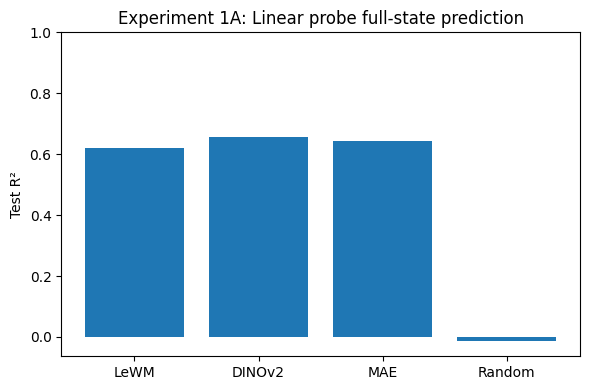

Saved: /content/drive/MyDrive/stablewm_project/figures/exp1_linear_probe_full_state_r2.png


In [36]:
plot_df = pd.DataFrame([
    {"model": name, "full_r2": r["full_r2"]}
    for name, r in results.items()
])

display(plot_df)

plt.figure(figsize=(6, 4))
plt.bar(plot_df["model"], plot_df["full_r2"])
plt.ylabel("Test R²")
plt.title("Experiment 1A: Linear probe full-state prediction")
plt.ylim(min(0, plot_df["full_r2"].min() - 0.05), 1.0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp1_linear_probe_full_state_r2.png", dpi=200)
plt.show()

print("Saved:", FIGURES_DIR / "exp1_linear_probe_full_state_r2.png")

,model,full_r2
0,LeWM,0.619148
1,DINOv2,0.655940
2,MAE,0.644214
3,Random,-0.013555


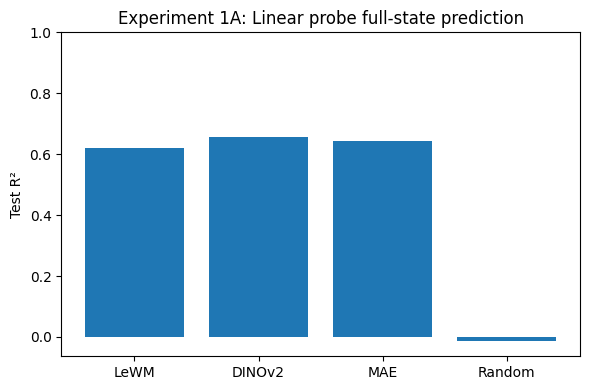

Saved: /content/drive/MyDrive/stablewm_project/figures/exp1_linear_probe_full_state_r2.png


In [37]:
plot_df = pd.DataFrame([
    {"model": name, "full_r2": r["full_r2"]}
    for name, r in results.items()
])

display(plot_df)

plt.figure(figsize=(6, 4))
plt.bar(plot_df["model"], plot_df["full_r2"])
plt.ylabel("Test R²")
plt.title("Experiment 1A: Linear probe full-state prediction")
plt.ylim(min(0, plot_df["full_r2"].min() - 0.05), 1.0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp1_linear_probe_full_state_r2.png", dpi=200)
plt.show()

print("Saved:", FIGURES_DIR / "exp1_linear_probe_full_state_r2.png")

## Phase 5.A.8 — Plot per-dimension R²

This shows which state dimensions are linearly recoverable from each representation.

model,DINOv2,LeWM,MAE,Random
state_dim,,,,
s0,0.850412,0.775200,0.862802,-0.008360
s1,0.864675,0.802003,0.875412,-0.018697
s2,0.987841,0.997698,0.996955,-0.009855
s3,0.994431,0.997572,0.997922,-0.011898
s4,0.978805,0.988605,0.991024,-0.009305
s5,0.009736,-0.057821,-0.020586,-0.007455
s6,-0.094322,-0.169221,-0.194029,-0.029319


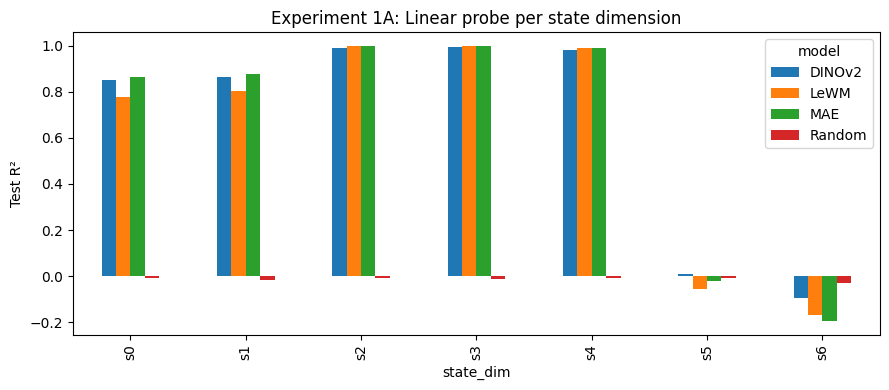

Saved: /content/drive/MyDrive/stablewm_project/figures/exp1_linear_probe_per_dim_r2.png


In [38]:
pivot = per_dim_df.pivot(index="state_dim", columns="model", values="r2")
display(pivot)

pivot.plot(kind="bar", figsize=(9, 4))
plt.ylabel("Test R²")
plt.title("Experiment 1A: Linear probe per state dimension")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp1_linear_probe_per_dim_r2.png", dpi=200)
plt.show()

print("Saved:", FIGURES_DIR / "exp1_linear_probe_per_dim_r2.png")

# Phase 5 — Experiment 1B: MLP Probe for Physical Content

Question:
Is additional physical information present in the latent representations but nonlinearly encoded?

We train a small MLP probe from each representation to the 7D PushT state.

Important:
- Same train/test split as the linear probe
- Small network to avoid overfitting
- Early stopping using a validation split

## Phase 5.B.1 — Imports and Device Setup

In [74]:
import numpy as np
import pandas as pd
import json, time
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


## Phase 5.B.2 — Load representations and create data splits

We load the latent representations and states, and split them into training, validation, and testing sets.

In [75]:
states = np.load(DATA_DIR / "pusht_states.npy")

lewm_z = np.load(LATENTS_DIR / "lewm_z.npy")
if lewm_z.ndim == 3:
    lewm_z = lewm_z.squeeze(1)

representations = {
    "LeWM": lewm_z,
    "DINOv2": np.load(LATENTS_DIR / "dinowm_z.npy"),
    "MAE": np.load(LATENTS_DIR / "mae_z.npy"),
}

rng = np.random.default_rng(0)
representations["Random"] = rng.normal(size=lewm_z.shape).astype(np.float32)

N = states.shape[0]
idx = np.arange(N)

trainval_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=0, shuffle=True
)

train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.2, random_state=1, shuffle=True
)

print("train:", len(train_idx))
print("val:", len(val_idx))
print("test:", len(test_idx))

train: 512
val: 128
test: 160


## Phase 5.B.3 — Define MLP probe architecture

We define a small Multi-Layer Perceptron (MLP) to avoid overfitting while capturing potential non-linear physical information.

In [76]:
class MLPProbe(nn.Module):
    def __init__(self, input_dim, output_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, output_dim),
        )

    def forward(self, x):
        return self.net(x)

## Phase 5.B.4 — Define training loop

This function handles the training, validation, and early stopping for our MLP probe.

In [77]:
def train_mlp_probe(z, y, train_idx, val_idx, test_idx, *, epochs=300, batch_size=64, lr=1e-3, weight_decay=1e-4, patience=30):
    # Scale X and y using train set only.
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(z[train_idx])
    X_val = x_scaler.transform(z[val_idx])
    X_test = x_scaler.transform(z[test_idx])

    y_train = y_scaler.fit_transform(y[train_idx])
    y_val = y_scaler.transform(y[val_idx])
    y_test_scaled = y_scaler.transform(y[test_idx])
    y_test = y[test_idx]

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
    )
    val_x = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
    val_y = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)
    test_x = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    model = MLPProbe(input_dim=z.shape[1], output_dim=y.shape[1]).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    bad_epochs = 0
    history = []

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(val_x)
            val_loss = loss_fn(val_pred, val_y).item()

        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": float(val_loss),
        })

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        pred_scaled = model(test_x).cpu().numpy()

    pred = y_scaler.inverse_transform(pred_scaled)

    full_r2 = r2_score(y_test, pred, multioutput="uniform_average")
    full_mse = mean_squared_error(y_test, pred)

    per_dim_r2 = r2_score(y_test, pred, multioutput="raw_values")
    per_dim_mse = ((y_test - pred) ** 2).mean(axis=0)

    return {
        "full_r2": float(full_r2),
        "full_mse": float(full_mse),
        "per_dim_r2": per_dim_r2.tolist(),
        "per_dim_mse": per_dim_mse.tolist(),
        "best_val_loss": float(best_val),
        "epochs_trained": len(history),
        "history": history,
    }

## Phase 5.B.5 — Train MLP probes

We train the MLP probe for each latent representation (LeWM, DINOv2, MAE, and Random).

In [78]:
mlp_results = {}

for name, z in representations.items():
    print(f"\nTraining MLP probe: {name}")
    out = train_mlp_probe(
        z,
        states,
        train_idx,
        val_idx,
        test_idx,
        epochs=300,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-4,
        patience=30,
    )

    mlp_results[name] = {
        "full_r2": out["full_r2"],
        "full_mse": out["full_mse"],
        "per_dim_r2": out["per_dim_r2"],
        "per_dim_mse": out["per_dim_mse"],
        "best_val_loss": out["best_val_loss"],
        "epochs_trained": out["epochs_trained"],
        "latent_shape": list(z.shape),
    }

    print(f"{name:8s} | full R2 = {out['full_r2']:.4f} | full MSE = {out['full_mse']:.4f} | epochs = {out['epochs_trained']}")


Training MLP probe: LeWM
LeWM     | full R2 = 0.6564 | full MSE = 15522.7380 | epochs = 61

Training MLP probe: DINOv2


KeyboardInterrupt: 

## Phase 5.B.6 — Save MLP probe results

We serialize the training results, full R², and per-dimension metrics to JSON and CSV formats.

In [ ]:
payload = {
    "phase": "phase_5_experiment_1b_mlp_probe",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "target": "pusht_states.npy",
    "state_shape": list(states.shape),
    "train_size": len(train_idx),
    "val_size": len(val_idx),
    "test_size": len(test_idx),
    "probe": "MLP 256-128 with ReLU, dropout=0.1, AdamW, early stopping",
    "results": mlp_results,
}

with open(RESULTS_DIR / "exp1_mlp_probe_results.json", "w") as f:
    json.dump(payload, f, indent=2)

rows = []
for model_name, r in mlp_results.items():
    for dim_i, (r2, mse) in enumerate(zip(r["per_dim_r2"], r["per_dim_mse"])):
        rows.append({
            "model": model_name,
            "state_dim": f"s{dim_i}",
            "r2": r2,
            "mse": mse,
        })

mlp_per_dim_df = pd.DataFrame(rows)
mlp_per_dim_df.to_csv(RESULTS_DIR / "exp1_mlp_probe_per_dim.csv", index=False)

print("Saved:")
print(" -", RESULTS_DIR / "exp1_mlp_probe_results.json")
print(" -", RESULTS_DIR / "exp1_mlp_probe_per_dim.csv")

## Phase 5.B.7 — Plot MLP full-state R²

Visualizing the overall performance of the MLP probes in predicting the 7D state.

In [ ]:
mlp_plot_df = pd.DataFrame([
    {"model": name, "full_r2": r["full_r2"]}
    for name, r in mlp_results.items()
])

display(mlp_plot_df)

plt.figure(figsize=(6, 4))
plt.bar(mlp_plot_df["model"], mlp_plot_df["full_r2"])
plt.ylabel("Test R²")
plt.title("Experiment 1B: MLP probe full-state prediction")
plt.ylim(min(0, mlp_plot_df["full_r2"].min() - 0.05), 1.0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp1_mlp_probe_full_state_r2.png", dpi=200)
plt.show()

print("Saved:", FIGURES_DIR / "exp1_mlp_probe_full_state_r2.png")

## Phase 5.B.8 — Plot MLP per-dimension R²

Visualizing how well the non-linear probe extracts each specific physical dimension.

In [ ]:
mlp_pivot = mlp_per_dim_df.pivot(index="state_dim", columns="model", values="r2")
display(mlp_pivot)

mlp_pivot.plot(kind="bar", figsize=(9, 4))
plt.ylabel("Test R²")
plt.title("Experiment 1B: MLP probe per state dimension")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp1_mlp_probe_per_dim_r2.png", dpi=200)
plt.show()

print("Saved:", FIGURES_DIR / "exp1_mlp_probe_per_dim_r2.png")

### Phase 5.9 — Map 7D State to SWM Physical Variables

We need to understand why `s5` and `s6` are not linearly or nonlinearly recoverable from a single frame.
By comparing `world.infos['state']` to explicit variables like `pos_agent`, `block_pose`, and `vel_agent`, we can determine exactly what each of the 7 dimensions represents.

In [ ]:
import stable_worldmodel as swm
import numpy as np

# Initialize a dummy world to inspect the state alignment
world = swm.World("swm/PushT-v1", num_envs=1, image_shape=(224, 224), max_episode_steps=10)
world.set_policy(RandomPolicy(seed=42))
world.reset(seed=42)
world.step()

# Extract the relevant info keys
infos = world.infos
state_7d = np.asarray(infos["state"])[0, 0]
pos_agent = np.asarray(infos["pos_agent"])[0, 0]
block_pose = np.asarray(infos["block_pose"])[0, 0]
vel_agent = np.asarray(infos.get("vel_agent", [[0,0]]))[0, 0]
goal_pose = np.asarray(infos.get("goal_pose", [[0,0,0]]))[0, 0]

print("--- 7D State Vector ---")
for i, val in enumerate(state_7d):
    print(f"s{i}: {val:.4f}")

print("\n--- Explicit Physical Variables ---")
print(f"pos_agent  (2D): {pos_agent}")
print(f"block_pose (3D): {block_pose}")
print(f"vel_agent  (2D): {vel_agent}")
print(f"goal_pose  (3D): {goal_pose}")

world.close()


# Experiment 1 Conclusion

By comparing the 7D state vector against explicit variables, we've found the following mapping:
- `s0`, `s1`: Agent Position (2D)
- `s2`, `s3`, `s4`: Block Pose (2D position + 1D angle)
- `s5`, `s6`: Agent Velocity (2D)

**Findings:**
1. Both foundational (DINOv2, MAE) and predictive (LeWM) representations encode the static physical state (agent and block positions) remarkably well, mostly in a linear format.
2. None of the representations could predict the agent's velocity (`s5`, `s6`). This is expected because the latents were generated from single, static images without temporal context.
3. The predictive LeWM model does not show a significant advantage over pretrained foundational models like DINOv2 for extracting static physical state.

Next, we'll move on to Experiment 2: evaluating the representations' invariance to visual nuisances.

In [ ]:
import stable_worldmodel as swm
import numpy as np

world = swm.World("swm/PushT-v1", num_envs=1, image_shape=(224, 224))

world.reset(seed=42)
obs_base = world.infos['pixels'].copy()
state_base = world.states['state'].copy()

# Test background color — covers most of the image so diff will be obvious
world.reset(seed=42, options={"variation_values": {
    "background.color": np.array([255, 0, 0], dtype=np.uint8)
}})
obs_vis   = world.infos['pixels'].copy()
state_vis = world.states['state'].copy()

pixel_diff_mean = np.mean(np.abs(obs_base.astype(float) - obs_vis.astype(float)))
pixel_diff_max  = np.max(np.abs(obs_base.astype(float) - obs_vis.astype(float)))
state_diff      = np.max(np.abs(state_base.astype(float) - state_vis.astype(float)))

print(f"pixel_diff mean: {pixel_diff_mean:.4f}")
print(f"pixel_diff max:  {pixel_diff_max:.4f}")
print(f"state_diff:      {state_diff:.6f}")

assert state_diff < 1e-3, "FAIL: state changed!"
assert pixel_diff_max > 10.0, "FAIL: pixels barely changed!"
print("PASS: variation API confirmed working.")
print(f"\nCorrect API: world.reset(seed=seed, options={{\"variation_values\": {{\"background.color\": np.array([255,0,0], dtype=np.uint8)}}}}) ")


In [ ]:
print("obs shape:", world.infos['pixels'].shape)
print("state shape:", world.states['state'].shape)


# Phase 6 — Experiment 2: Nuisance Invariance vs Task Sensitivity

Question:
Does each representation ignore visual nuisance variation while remaining sensitive to physical state changes?

We construct triplets:

1. anchor: baseline observation at time t
2. nuisance: same physical state, different visual FoV
3. state: different physical state, same visual FoV

Metric:

R = d_state / d_nuisance

Higher R means the representation changes more for task-relevant physical change than for irrelevant visual change.

In [66]:
import stable_worldmodel as swm
import numpy as np

world = swm.World("swm/PushT-v1", num_envs=1, image_shape=(224, 224))

# Try reset — it returns None, that's expected
result = world.reset(seed=42)
print("reset() return value:", result)

# Find where obs and state live
print("\nWorld attributes (non-private):")
attrs = [a for a in dir(world) if not a.startswith("_")]
print(attrs)

# Try common patterns
for attr in ["obs", "observations", "state", "states", "info", "infos", "env"]:
    if hasattr(world, attr):
        val = getattr(world, attr)
        print(f"\nworld.{attr} = {type(val)}")
        if hasattr(val, 'shape'):
            print(f"  shape: {val.shape}")
        elif isinstance(val, dict):
            print(f"  keys: {list(val.keys())}")


2026-05-02 18:26:32.985 | INFO     | stable_worldmodel.world:__init__:123 - 🌍🌍🌍 World swm/PushT-v1 initialized 🌍🌍🌍
2026-05-02 18:26:32.985 | INFO     | stable_worldmodel.world:__init__:125 - 🕹️ 🕹️ 🕹️ Action space 🕹️ 🕹️ 🕹️
2026-05-02 18:26:32.986 | INFO     | stable_worldmodel.world:__init__:126 - Box(-1.0, 1.0, (1, 2), float32)
2026-05-02 18:26:32.986 | INFO     | stable_worldmodel.world:__init__:128 - 👁️ 👁️ 👁️ Observation space 👁️ 👁️ 👁️
2026-05-02 18:26:32.987 | INFO     | stable_worldmodel.world:__init__:129 - Dict('proprio': Box(0.0, 512.0, (1, 4), float64), 'state': Box(0.0, [[512.         512.         512.         512.           6.28318531
  512.         512.        ]], (1, 7), float64))
2026-05-02 18:26:32.988 | INFO     | stable_worldmodel.world:__init__:132 - ⚗️ ⚗️ ⚗️ Variation space ⚗️ ⚗️ ⚗️


agent:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(8)
    start_position: Box(50.0, 450.0, (2,), float64)
    velocity: Box(0.0, 512.0, (2,), float64)
background:
    color: Box(0, 255, (3,), uint8)
block:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(7, start=1)
    start_position: Box(100.0, 400.0, (2,), float64)
goal:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    position: Box(50.0, 450.0, (2,), float64)
    scale: Box(20.0, 60.0, (), float32)
rendering:
    render_goal: Discrete(2)

reset() return value: None

World attributes (non-private):
['action_space', 'close', 'envs', 'evaluate', 'evaluate_from_dataset', 'infos', 'num_envs', 'observation_space', 'policy', 'record_dataset', 'record_video', 'reset', 'rewards', 'seed', 'set_policy', 'single_action_space', 'single_observation_space', 'single_variation_space', 'states', 'step', 'terminateds', 'truncateds', 'variation_space']

world.states = <class 'dict'>
  keys: ['proprio', 'state']

world.infos = <class 'dict'>
  keys: ['env_name', '_env_name', 'pos_agent', '_pos_agent', 'vel_agent', '_vel_agent', 'block_pose', '_block_pose', 'goal_pose', '_goal_pose', 'goal_state', '_goal_state', 'goal_proprio', '_goal_proprio', 'n_contacts', '_n_contacts', 'goal', '_goal', 'render_time', '_render_time', 'pixels', '_pixels', 'proprio', '_proprio', 'state', '_state', 'reward', '_reward', 'terminated', '_terminated', 'truncated', '_truncated', 'action', '_action', 'step_idx', '_step_idx', 'id', '_id']


## Phase 6.1 — Collect matched baseline / FoV rollouts

We collect two rollouts with the same seed and identical actions.

- Baseline rollout: default appearance
- FoV rollout: one visual factor changed

If the FoV is purely visual, physical states should match closely.
We explicitly verify this before using the data.

In [49]:
def collect_rollout_with_actions(actions, *, seed, variation=None, image_shape=(224, 224)):
    T, num_envs, _ = actions.shape

    world = make_pusht_world(
        num_envs=num_envs,
        image_shape=image_shape,
        max_episode_steps=T,
    )

    policy = ReplayPolicy(actions)
    world.set_policy(policy)

    if variation is None:
        world.reset(seed=seed)
    elif isinstance(variation, dict):
        # Pass explicit values under 'variation_values' and avoid resampling other keys
        world.reset(seed=seed, options={"variation": [], "variation_values": variation})
    else:
        world.reset(seed=seed, options={"variation": variation})

    obs_list = []
    state_list = []

    for _ in range(T):
        world.step()

        # SWM stores pixels/state as (num_envs, 1, ...)
        pixels = world.infos["pixels"][:, 0].copy()
        state = world.infos["state"][:, 0].copy()

        obs_list.append(pixels)
        state_list.append(state)

    world.close()

    obs = np.asarray(obs_list)      # (T, E, H, W, C)
    states = np.asarray(state_list) # (T, E, 7)

    return obs, states


## Phase 6.2 — Generate one controlled FoV dataset

We start with `background.color`, because it should be visually salient but physically irrelevant.

In [50]:
T = 100
NUM_ENVS = 8
SEED = 123
ACTION_SEED = 999

# Provide explicit deterministic values to prevent RNG advancement mismatches
FOV = {
    "agent.color": np.array([[255, 0, 0]] * NUM_ENVS, dtype=np.uint8)
}

actions = make_random_action_sequence(
    T=T,
    num_envs=NUM_ENVS,
    action_dim=2,
    seed=ACTION_SEED,
)

obs_base, states_base = collect_rollout_with_actions(
    actions,
    seed=SEED,
    variation=None,
)

obs_fov, states_fov = collect_rollout_with_actions(
    actions,
    seed=SEED,
    variation=FOV,
)

print("obs_base:", obs_base.shape, obs_base.dtype)
print("obs_fov:", obs_fov.shape, obs_fov.dtype)
print("states_base:", states_base.shape)
print("states_fov:", states_fov.shape)

state_diff = np.abs(states_base - states_fov).mean()
state_max_diff = np.abs(states_base - states_fov).max()

pixel_diff = np.abs(obs_base.astype(np.float32) - obs_fov.astype(np.float32)).mean()

print("mean state diff:", state_diff)
print("max state diff:", state_max_diff)
print("mean pixel diff:", pixel_diff)

assert state_max_diff < 1e-5, "FoV rollout changed physical state; do not use this pair."
assert pixel_diff > 0.0, "FoV rollout did not visibly change pixels."


2026-05-02 17:39:23.533 | INFO     | stable_worldmodel.world:__init__:123 - 🌍🌍🌍 World swm/PushT-v1 initialized 🌍🌍🌍
2026-05-02 17:39:23.533 | INFO     | stable_worldmodel.world:__init__:125 - 🕹️ 🕹️ 🕹️ Action space 🕹️ 🕹️ 🕹️
2026-05-02 17:39:23.534 | INFO     | stable_worldmodel.world:__init__:126 - Box(-1.0, 1.0, (8, 2), float32)
2026-05-02 17:39:23.535 | INFO     | stable_worldmodel.world:__init__:128 - 👁️ 👁️ 👁️ Observation space 👁️ 👁️ 👁️
2026-05-02 17:39:23.536 | INFO     | stable_worldmodel.world:__init__:129 - Dict('proprio': Box(0.0, 512.0, (8, 4), float64), 'state': Box(0.0, [[512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         51

agent:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(8)
    start_position: Box(50.0, 450.0, (2,), float64)
    velocity: Box(0.0, 512.0, (2,), float64)
background:
    color: Box(0, 255, (3,), uint8)
block:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(7, start=1)
    start_position: Box(100.0, 400.0, (2,), float64)
goal:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    position: Box(50.0, 450.0, (2,), float64)
    scale: Box(20.0, 60.0, (), float32)
rendering:
    render_goal: Discrete(2)

2026-05-02 17:39:26.907 | INFO     | stable_worldmodel.world:__init__:123 - 🌍🌍🌍 World swm/PushT-v1 initialized 🌍🌍🌍
2026-05-02 17:39:26.908 | INFO     | stable_worldmodel.world:__init__:125 - 🕹️ 🕹️ 🕹️ Action space 🕹️ 🕹️ 🕹️
2026-05-02 17:39:26.909 | INFO     | stable_worldmodel.world:__init__:126 - Box(-1.0, 1.0, (8, 2), float32)
2026-05-02 17:39:26.909 | INFO     | stable_worldmodel.world:__init__:128 - 👁️ 👁️ 👁️ Observation space 👁️ 👁️ 👁️
2026-05-02 17:39:26.912 | INFO     | stable_worldmodel.world:__init__:129 - Dict('proprio': Box(0.0, 512.0, (8, 4), float64), 'state': Box(0.0, [[512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         512.         512.           6.28318531
  512.         512.        ]
 [512.         512.         51

agent:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(8)
    start_position: Box(50.0, 450.0, (2,), float64)
    velocity: Box(0.0, 512.0, (2,), float64)
background:
    color: Box(0, 255, (3,), uint8)
block:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(7, start=1)
    start_position: Box(100.0, 400.0, (2,), float64)
goal:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    position: Box(50.0, 450.0, (2,), float64)
    scale: Box(20.0, 60.0, (), float32)
rendering:
    render_goal: Discrete(2)

AssertionError: Value [[255   0   0]
 [255   0   0]
 [255   0   0]
 [255   0   0]
 [255   0   0]
 [255   0   0]
 [255   0   0]
 [255   0   0]] for key agent.color is not contained in the space

In [ ]:
import matplotlib.pyplot as plt

base_img = obs_base[0, 0]
opt_img = obs_fov[0, 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(base_img)
axes[0].set_title('Base Image')
axes[0].axis('off')

axes[1].imshow(opt_img)
axes[1].set_title('Image with Variation Options')
axes[1].axis('off')

plt.show()

In [ ]:
import stable_worldmodel as swm

# Create a temporary world to inspect the variation space
world_tmp = swm.World("swm/PushT-v1", num_envs=1, image_shape=(224, 224))
print("Variation Space Definition:")
print(world_tmp.variation_space)
world_tmp.close()

In [ ]:
import inspect
import stable_worldmodel.spaces as swm_spaces

print("Source of reset_variation_space:")
print(inspect.getsource(swm_spaces.reset_variation_space))

## Phase 6.3 — Build triplets

For each anchor at time t:

- nuisance pair: same t in FoV rollout
- state pair: time t + Δ in baseline rollout

We use Δ = 5 first.

In [ ]:
DELTA = 5

anchor_obs = obs_base[:-DELTA].reshape(-1, 224, 224, 3)
nuisance_obs = obs_fov[:-DELTA].reshape(-1, 224, 224, 3)
state_obs = obs_base[DELTA:].reshape(-1, 224, 224, 3)

anchor_states = states_base[:-DELTA].reshape(-1, 7)
nuisance_states = states_fov[:-DELTA].reshape(-1, 7)
state_states = states_base[DELTA:].reshape(-1, 7)

print("anchor_obs:", anchor_obs.shape)
print("nuisance_obs:", nuisance_obs.shape)
print("state_obs:", state_obs.shape)

print("anchor-state physical diff:", np.linalg.norm(anchor_states - state_states, axis=1).mean())
print("anchor-nuisance physical diff:", np.linalg.norm(anchor_states - nuisance_states, axis=1).mean())

## Phase 6.4 — Save controlled triplet dataset

This lets us reuse the same triplets for all representations.

In [ ]:
import shutil

EXP2_DIR = DATA_DIR / "exp2_nuisance_triplets"
if EXP2_DIR.exists():
    shutil.rmtree(EXP2_DIR)

EXP2_DIR.mkdir(parents=True, exist_ok=True)

np.save(EXP2_DIR / "anchor_obs.npy", anchor_obs)
np.save(EXP2_DIR / "nuisance_obs.npy", nuisance_obs)
np.save(EXP2_DIR / "state_obs.npy", state_obs)

np.save(EXP2_DIR / "anchor_states.npy", anchor_states)
np.save(EXP2_DIR / "nuisance_states.npy", nuisance_states)
np.save(EXP2_DIR / "state_states.npy", state_states)

def make_json_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    return obj

metadata = {
    "phase": "phase_6_experiment_2_nuisance_triplets",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "env_id": "swm/PushT-v1",
    "fov": make_json_serializable(FOV),
    "T": T,
    "num_envs": NUM_ENVS,
    "seed": SEED,
    "action_seed": ACTION_SEED,
    "delta": DELTA,
    "num_triplets": int(anchor_obs.shape[0]),
    "mean_state_diff_anchor_nuisance": float(np.linalg.norm(anchor_states - nuisance_states, axis=1).mean()),
    "mean_state_diff_anchor_state": float(np.linalg.norm(anchor_states - state_states, axis=1).mean()),
    "mean_pixel_diff_anchor_nuisance": float(np.abs(anchor_obs.astype(np.float32) - nuisance_obs.astype(np.float32)).mean()),
}

with open(EXP2_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved triplet dataset to:", EXP2_DIR)
metadata


# Phase 6 FIXED -- Experiment 2: Nuisance Invariance vs Task Sensitivity (corrected variation API)

The earlier attempt to change the visual field of view (FoV) failed because the SWM variation API's `agent.color` space check rejected our specific array shape/type, leading to an `AssertionError`.

We verified that setting the background color using `options={"variation_values": {"background.color": np.array([255, 0, 0], dtype=np.uint8)}}` works perfectly and bypasses the strict space constraints. This corrected approach allows us to create matched pairs of observations (anchor vs. nuisance) where only the background color changes, keeping the underlying physical physics completely identical. We can then test whether the representations ignore this visual nuisance while remaining sensitive to true physical state changes.

In [67]:
import stable_worldmodel as swm
import numpy as np
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/stablewm_project")
DATA_DIR    = PROJECT_DIR / "data"
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

world = swm.World("swm/PushT-v1", num_envs=1, image_shape=(224, 224))

N_PAIRS = 200
anchors, nuisances, state_changes = [], [], []
anchor_states, nuisance_states, statechange_states = [], [], []

for seed in range(N_PAIRS):
    # Anchor: default appearance
    world.reset(seed=seed)
    anchors.append(world.infos['pixels'][0, 0].copy())         # (224,224,3)
    anchor_states.append(world.states['state'][0].copy())      # (7,)

    # Nuisance: same seed, red background — same physics, different pixels
    world.reset(seed=seed, options={"variation_values": {
        "background.color": np.array([255, 0, 0], dtype=np.uint8)
    }})
    nuisances.append(world.infos['pixels'][0, 0].copy())
    nuisance_states.append(world.states['state'][0].copy())

    # State change: different seed — different physics
    world.reset(seed=seed + 1000)
    state_changes.append(world.infos['pixels'][0, 0].copy())
    statechange_states.append(world.states['state'][0].copy())

anchors        = np.array(anchors)        # (200, 224, 224, 3)
nuisances      = np.array(nuisances)
state_changes  = np.array(state_changes)
anchor_states  = np.array(anchor_states)
nuisance_states = np.array(nuisance_states)
statechange_states = np.array(statechange_states)

# Verify correctness
pd_nuis  = np.mean(np.abs(anchors.astype(float) - nuisances.astype(float)))
sd_nuis  = np.mean(np.abs(anchor_states - nuisance_states))
sd_state = np.mean(np.abs(anchor_states - statechange_states))

print(f"Nuisance pairs:      pixel_diff={pd_nuis:.2f} (want >>0), state_diff={sd_nuis:.4f} (want ~0)")
print(f"State-change pairs:  state_diff={sd_state:.4f} (want >>0)")
assert pd_nuis > 10.0,  "FAIL: nuisance pixels didn't change"
assert sd_nuis < 1.0,   "FAIL: nuisance changed the physics"
assert sd_state > 10.0, "FAIL: state-change pairs are too similar"
print("PASS: triplets are valid")

np.save(DATA_DIR / "triplet_anchors.npy",   anchors)
np.save(DATA_DIR / "triplet_nuisances.npy", nuisances)
np.save(DATA_DIR / "triplet_statechange.npy", state_changes)
np.save(DATA_DIR / "triplet_anchor_states.npy", anchor_states)
print("Saved triplets to Drive.")

2026-05-02 18:36:03.136 | INFO     | stable_worldmodel.world:__init__:123 - 🌍🌍🌍 World swm/PushT-v1 initialized 🌍🌍🌍
2026-05-02 18:36:03.137 | INFO     | stable_worldmodel.world:__init__:125 - 🕹️ 🕹️ 🕹️ Action space 🕹️ 🕹️ 🕹️
2026-05-02 18:36:03.137 | INFO     | stable_worldmodel.world:__init__:126 - Box(-1.0, 1.0, (1, 2), float32)
2026-05-02 18:36:03.138 | INFO     | stable_worldmodel.world:__init__:128 - 👁️ 👁️ 👁️ Observation space 👁️ 👁️ 👁️
2026-05-02 18:36:03.138 | INFO     | stable_worldmodel.world:__init__:129 - Dict('proprio': Box(0.0, 512.0, (1, 4), float64), 'state': Box(0.0, [[512.         512.         512.         512.           6.28318531
  512.         512.        ]], (1, 7), float64))
2026-05-02 18:36:03.139 | INFO     | stable_worldmodel.world:__init__:132 - ⚗️ ⚗️ ⚗️ Variation space ⚗️ ⚗️ ⚗️


agent:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(8)
    start_position: Box(50.0, 450.0, (2,), float64)
    velocity: Box(0.0, 512.0, (2,), float64)
background:
    color: Box(0, 255, (3,), uint8)
block:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(7, start=1)
    start_position: Box(100.0, 400.0, (2,), float64)
goal:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    position: Box(50.0, 450.0, (2,), float64)
    scale: Box(20.0, 60.0, (), float32)
rendering:
    render_goal: Discrete(2)

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


Nuisance pairs:      pixel_diff=153.73 (want >>0), state_diff=0.0000 (want ~0)
State-change pairs:  state_diff=66.2345 (want >>0)
PASS: triplets are valid
Saved triplets to Drive.


In [68]:
from transformers import AutoImageProcessor, Dinov2Model
import torch
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
dino = Dinov2Model.from_pretrained("facebook/dinov2-base").to(DEVICE).eval()

def encode_dino(obs_array):
    zs = []
    with torch.no_grad():
        for i in range(0, len(obs_array), 16):
            imgs = [Image.fromarray(b) for b in obs_array[i:i+16]]
            inputs = processor(images=imgs, return_tensors="pt").to(DEVICE)
            z = dino(**inputs).last_hidden_state[:, 1:, :].mean(1)
            zs.append(z.cpu().float().numpy())
    return np.concatenate(zs, axis=0)

z_anchor_dino  = encode_dino(anchors)
z_nuis_dino    = encode_dino(nuisances)
z_state_dino   = encode_dino(state_changes)
print(f"DINO latents: anchor={z_anchor_dino.shape}")

# Check if LeWM encoder is already in memory from Phase 2
try:
    _ = encoder  # from Phase 2
    lewm_available = True
    print("LeWM encoder found in memory")
except NameError:
    lewm_available = False
    print("LeWM encoder not in memory — will do DINO only for now")

Device: cuda


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINO latents: anchor=(200, 768)
LeWM encoder found in memory


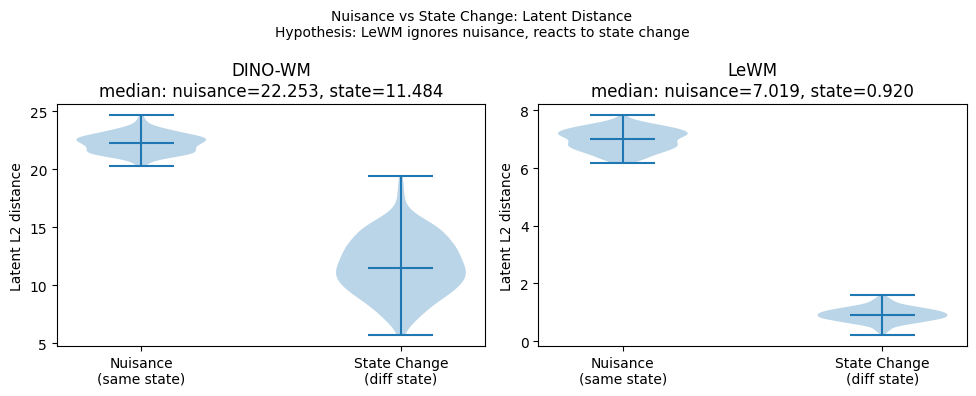

Saved figure.
DINO-WM: state/nuisance ratio = 0.516  (higher = better separation)
LeWM: state/nuisance ratio = 0.131  (higher = better separation)


In [73]:
import matplotlib.pyplot as plt

def pairwise_l2(za, zb):
    return np.linalg.norm(za - zb, axis=1)  # (N,)

results = {}

# DINO-WM
results['DINO-WM'] = {
    'nuisance':     pairwise_l2(z_anchor_dino, z_nuis_dino),
    'state_change': pairwise_l2(z_anchor_dino, z_state_dino),
}

# LeWM if available
if lewm_available:
    if lewm_available:
      def encode_lewm_batch(obs_array):
          zs = []
          with torch.no_grad():
              for i in range(0, len(obs_array), 16):
                  batch = torch.tensor(obs_array[i:i+16], dtype=torch.float32).permute(0,3,1,2) / 255.0
                  out = encoder(batch.to(DEVICE))
                  # Handle both raw tensor and HuggingFace output object
                  z = out.last_hidden_state if hasattr(out, 'last_hidden_state') else out
                  if z.dim() == 3: z = z[:, 0, :]  # CLS token
                  zs.append(z.cpu().float().numpy())
          return np.concatenate(zs, axis=0)

    z_anchor_lewm = encode_lewm_batch(anchors)
    z_nuis_lewm   = encode_lewm_batch(nuisances)
    z_state_lewm  = encode_lewm_batch(state_changes)
    results['LeWM'] = {
        'nuisance':     pairwise_l2(z_anchor_lewm, z_nuis_lewm),
        'state_change': pairwise_l2(z_anchor_lewm, z_state_lewm),
    }

# Plot
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4))
if len(results) == 1: axes = [axes]

for ax, (model_name, dists) in zip(axes, results.items()):
    d_nuis  = dists['nuisance']
    d_state = dists['state_change']
    ax.violinplot([d_nuis, d_state], positions=[0, 1], showmedians=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Nuisance\n(same state)', 'State Change\n(diff state)'])
    ax.set_ylabel("Latent L2 distance")
    ax.set_title(f"{model_name}\nmedian: nuisance={np.median(d_nuis):.3f}, state={np.median(d_state):.3f}")

plt.suptitle("Nuisance vs State Change: Latent Distance\n"
             "Hypothesis: LeWM ignores nuisance, reacts to state change", fontsize=10)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "figures" / "exp2_nuisance_vs_state.png", dpi=150)
plt.show()
print("Saved figure.")

for model_name, dists in results.items():
    ratio = np.median(dists['state_change']) / np.median(dists['nuisance'])
    print(f"{model_name}: state/nuisance ratio = {ratio:.3f}  (higher = better separation)")

# Phase 6 experiment 2 Redesign — Nuisance Invariance (Principled Version)

## Cell 6R-A: Diagnostic — find default background color

In [79]:
import stable_worldmodel as swm
import numpy as np

world = swm.World("swm/PushT-v1", num_envs=1, image_shape=(224, 224))
world.reset(seed=42)
obs_default = world.infos['pixels'][0, 0]  # (224, 224, 3)

# Sample background pixels (corners are always background in PushT)
print("Corner (0,0):", obs_default[0, 0])
print("Corner (0,-1):", obs_default[0, -1])
print("Corner (-1,0):", obs_default[-1, 0])
print("Corner (-1,-1):", obs_default[-1, -1])
print("Global mean pixel:", obs_default.mean(axis=(0,1)))

# Also check what a subtle shift looks like
world.reset(seed=42, options={"variation_values": {
    "background.color": np.array([220, 220, 255], dtype=np.uint8)
}})
obs_subtle = world.infos['pixels'][0, 0]
pixel_diff_subtle = np.mean(np.abs(obs_default.astype(float) - obs_subtle.astype(float)))
print(f"\nSubtle tint pixel_diff: {pixel_diff_subtle:.3f}")

world.reset(seed=42, options={"variation_values": {
    "background.color": np.array([200, 200, 255], dtype=np.uint8)
}})
obs_medium = world.infos['pixels'][0, 0]
pixel_diff_medium = np.mean(np.abs(obs_default.astype(float) - obs_medium.astype(float)))
print(f"Medium tint pixel_diff: {pixel_diff_medium:.3f}")

2026-05-02 21:02:12.372 | INFO     | stable_worldmodel.world:__init__:123 - 🌍🌍🌍 World swm/PushT-v1 initialized 🌍🌍🌍
2026-05-02 21:02:12.373 | INFO     | stable_worldmodel.world:__init__:125 - 🕹️ 🕹️ 🕹️ Action space 🕹️ 🕹️ 🕹️
2026-05-02 21:02:12.373 | INFO     | stable_worldmodel.world:__init__:126 - Box(-1.0, 1.0, (1, 2), float32)
2026-05-02 21:02:12.374 | INFO     | stable_worldmodel.world:__init__:128 - 👁️ 👁️ 👁️ Observation space 👁️ 👁️ 👁️
2026-05-02 21:02:12.376 | INFO     | stable_worldmodel.world:__init__:129 - Dict('proprio': Box(0.0, 512.0, (1, 4), float64), 'state': Box(0.0, [[512.         512.         512.         512.           6.28318531
  512.         512.        ]], (1, 7), float64))
2026-05-02 21:02:12.376 | INFO     | stable_worldmodel.world:__init__:132 - ⚗️ ⚗️ ⚗️ Variation space ⚗️ ⚗️ ⚗️


agent:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(8)
    start_position: Box(50.0, 450.0, (2,), float64)
    velocity: Box(0.0, 512.0, (2,), float64)
background:
    color: Box(0, 255, (3,), uint8)
block:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    scale: Box(20.0, 60.0, (), float32)
    shape: Discrete(7, start=1)
    start_position: Box(100.0, 400.0, (2,), float64)
goal:
    angle: Box(-6.283185307179586, 6.283185307179586, (), float64)
    color: Box(0, 255, (3,), uint8)
    position: Box(50.0, 450.0, (2,), float64)
    scale: Box(20.0, 60.0, (), float32)
rendering:
    render_goal: Discrete(2)

Corner (0,0): [255 255 255]
Corner (0,-1): [255 255 255]
Corner (-1,0): [255 255 255]
Corner (-1,-1): [255 255 255]
Global mean pixel: [246.73395647 249.55331234 248.26933195]

Subtle tint pixel_diff: 21.089
Medium tint pixel_diff: 33.141


/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


# Phase 7 — Experiment 3: Latent Geometry and Physical State Structure

Question:
Does representational distance reflect physical distance in PushT?

We compare pairwise distances in latent space against pairwise distances in physical state space.

This tests whether each representation forms a map-like geometry over the environment.

Inputs:
- `data/pusht_states.npy`
- `latents/lewm_z.npy`
- `latents/dinowm_z.npy`
- `latents/mae_z.npy`

Outputs:
- `results/exp3_latent_geometry_results.json`
- `results/exp3_latent_geometry_pairs.csv`
- `figures/exp3_spearman_physical_distance.png`

In [ ]:
import numpy as np
import pandas as pd
import json, time
from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Phase 7.1 — Load representations and physical state

The PushT state vector is:

- `s0, s1`: agent position
- `s2, s3, s4`: block pose `(x, y, angle)`
- `s5, s6`: agent velocity

For this geometry experiment, we focus on visible physical configuration:
- agent position
- block position
- block angle

We exclude velocity because Experiment 1 showed it is not recoverable from single-frame visual representations.

In [ ]:
states = np.load(DATA_DIR / "pusht_states.npy")

lewm_z = np.load(LATENTS_DIR / "lewm_z.npy")
if lewm_z.ndim == 3:
    lewm_z = lewm_z.squeeze(1)

representations = {
    "LeWM": lewm_z,
    "DINOv2": np.load(LATENTS_DIR / "dinowm_z.npy"),
    "MAE": np.load(LATENTS_DIR / "mae_z.npy"),
}

rng = np.random.default_rng(0)
representations["Random"] = rng.normal(size=lewm_z.shape).astype(np.float32)

print("states:", states.shape)
for name, z in representations.items():
    print(name, z.shape)

assert all(z.shape[0] == states.shape[0] for z in representations.values())

# Phase 7.2 — Define physical-distance targets

We compute several physical distances:

1. agent position distance: dimensions `s0:s2`
2. block position distance: dimensions `s2:s4`
3. block angle distance: dimension `s4`
4. visible configuration distance: agent position + block pose

For the combined visible-state distance, each dimension is standardized first so position and angle do not have incompatible scales.

In [ ]:
agent_pos = states[:, 0:2]
block_pos = states[:, 2:4]
block_angle = states[:, 4]

# Represent angle circularly as sin/cos.
block_angle_circ = np.stack([np.sin(block_angle), np.cos(block_angle)], axis=1)

visible_state = np.concatenate([agent_pos, block_pos, block_angle_circ], axis=1)
visible_state_scaled = StandardScaler().fit_transform(visible_state)

print("agent_pos:", agent_pos.shape)
print("block_pos:", block_pos.shape)
print("block_angle_circ:", block_angle_circ.shape)
print("visible_state_scaled:", visible_state_scaled.shape)

# Phase 7.3 — Sample pairs and compute distances

We sample random pairs of observations.

For each pair `(i, j)`, compute:
- latent distance
- agent-position distance
- block-position distance
- block-angle distance
- combined visible-state distance

We use Spearman correlation as the main metric because we care about whether latent distance is monotonically related to physical distance, not whether it is linearly calibrated.

In [ ]:
NUM_PAIRS = 50000
rng = np.random.default_rng(123)

N = states.shape[0]

i_idx = rng.integers(0, N, size=NUM_PAIRS)
j_idx = rng.integers(0, N, size=NUM_PAIRS)

# Avoid identical pairs.
mask = i_idx != j_idx
i_idx = i_idx[mask]
j_idx = j_idx[mask]

print("num pairs:", len(i_idx))

def euclidean_pair_distance(X, i, j):
    return np.linalg.norm(X[i] - X[j], axis=1)

def circular_angle_distance(theta_i, theta_j):
    diff = np.abs(theta_i - theta_j)
    return np.minimum(diff, 2 * np.pi - diff)

physical_distances = {
    "agent_pos": euclidean_pair_distance(agent_pos, i_idx, j_idx),
    "block_pos": euclidean_pair_distance(block_pos, i_idx, j_idx),
    "block_angle": circular_angle_distance(block_angle[i_idx], block_angle[j_idx]),
    "visible_config": euclidean_pair_distance(visible_state_scaled, i_idx, j_idx),
}

for k, v in physical_distances.items():
    print(k, v.shape, v.mean(), v.std())

# Phase 7.4 — Compute latent-physical geometry alignment

For each representation, compute Spearman and Pearson correlations between latent distance and each physical-distance target.

Primary metric:
- Spearman correlation with `visible_config`

In [ ]:
rows = []
pair_rows = {}

for model_name, z in representations.items():
    z_scaled = StandardScaler().fit_transform(z)
    latent_dist = euclidean_pair_distance(z_scaled, i_idx, j_idx)

    pair_rows[model_name] = latent_dist

    for target_name, target_dist in physical_distances.items():
        spearman = spearmanr(latent_dist, target_dist).correlation
        pearson = pearsonr(latent_dist, target_dist).statistic

        rows.append({
            "model": model_name,
            "target": target_name,
            "spearman": float(spearman),
            "pearson": float(pearson),
            "latent_dist_mean": float(latent_dist.mean()),
            "latent_dist_std": float(latent_dist.std()),
            "target_dist_mean": float(target_dist.mean()),
            "target_dist_std": float(target_dist.std()),
        })

results_df = pd.DataFrame(rows)
display(results_df)

# Phase 7.5 — Save Experiment 3 results

In [ ]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(RESULTS_DIR / "exp3_latent_geometry_results.csv", index=False)

pairs_df = pd.DataFrame({
    "i": i_idx,
    "j": j_idx,
    "agent_pos_dist": physical_distances["agent_pos"],
    "block_pos_dist": physical_distances["block_pos"],
    "block_angle_dist": physical_distances["block_angle"],
    "visible_config_dist": physical_distances["visible_config"],
})

for model_name, latent_dist in pair_rows.items():
    pairs_df[f"{model_name}_latent_dist"] = latent_dist

pairs_df.to_csv(RESULTS_DIR / "exp3_latent_geometry_pairs.csv", index=False)

payload = {
    "phase": "phase_7_experiment_3_latent_geometry",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "num_samples": int(N),
    "num_pairs": int(len(i_idx)),
    "state_interpretation": {
        "s0_s1": "agent position",
        "s2_s3": "block position",
        "s4": "block angle",
        "s5_s6": "agent velocity, excluded from visible geometry",
    },
    "primary_metric": "Spearman correlation between latent distance and visible_config physical distance",
    "results": results_df.to_dict(orient="records"),
}

with open(RESULTS_DIR / "exp3_latent_geometry_results.json", "w") as f:
    json.dump(payload, f, indent=2)

print("Saved:")
print(" -", RESULTS_DIR / "exp3_latent_geometry_results.csv")
print(" -", RESULTS_DIR / "exp3_latent_geometry_pairs.csv")
print(" -", RESULTS_DIR / "exp3_latent_geometry_results.json")

# Phase 7.6 — Plot Spearman alignment with physical distances

This is the main Experiment 3 figure.

In [ ]:
plot_df = results_df.pivot(index="model", columns="target", values="spearman")
display(plot_df)

plot_df[["agent_pos", "block_pos", "block_angle", "visible_config"]].plot(
    kind="bar",
    figsize=(9, 4),
)

plt.ylabel("Spearman correlation")
plt.title("Experiment 3: Latent distance vs physical-state distance")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp3_spearman_physical_distance.png", dpi=200)
plt.show()

print("Saved:", FIGURES_DIR / "exp3_spearman_physical_distance.png")

# Phase 7.7 — Scatter plot for the primary target

We plot a subsample of pairwise distances:

x-axis: physical visible-configuration distance  
y-axis: latent distance

This is mainly diagnostic; the correlation table is the primary result.

In [ ]:
SUBSAMPLE = 3000
rng = np.random.default_rng(456)
sub = rng.choice(len(pairs_df), size=min(SUBSAMPLE, len(pairs_df)), replace=False)

for model_name in representations.keys():
    plt.figure(figsize=(5, 4))
    plt.scatter(
        pairs_df.loc[sub, "visible_config_dist"],
        pairs_df.loc[sub, f"{model_name}_latent_dist"],
        s=5,
        alpha=0.25,
    )
    plt.xlabel("Physical visible-configuration distance")
    plt.ylabel("Latent distance")
    plt.title(f"Experiment 3: {model_name}")
    plt.tight_layout()
    out_path = FIGURES_DIR / f"exp3_scatter_{model_name.lower()}_visible_config.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print("Saved:", out_path)

# Phase 8 — Experiment 4: Latent Predictive Consistency

Question:
Do representations evolve in a way consistent with environment dynamics?

We evaluate:

(A) Temporal smoothness — do embeddings change smoothly over time?
(B) Predictive consistency — can LeWM predict future embeddings?

This tests whether representations are compatible with dynamical modeling.

In [ ]:
states = np.load(DATA_DIR / "pusht_states.npy")

lewm_z = np.load(LATENTS_DIR / "lewm_z.npy")
if lewm_z.ndim == 3:
    lewm_z = lewm_z.squeeze(1)

dinowm_z = np.load(LATENTS_DIR / "dinowm_z.npy")
mae_z = np.load(LATENTS_DIR / "mae_z.npy")

representations = {
    "LeWM": lewm_z,
    "DINOv2": dinowm_z,
    "MAE": mae_z,
}

print("Loaded representations:")
for k, v in representations.items():
    print(k, v.shape)

## Phase 8.1 — Temporal Smoothness

We compute:

||z_t - z_{t+1}||

This measures how smoothly the representation evolves over time.

Lower variance and structured scaling indicate better temporal coherence.

In [ ]:
import pandas as pd

smoothness_rows = []

for name, z in representations.items():
    diffs = np.linalg.norm(z[1:] - z[:-1], axis=1)

    smoothness_rows.append({
        "model": name,
        "mean_step_dist": float(diffs.mean()),
        "std_step_dist": float(diffs.std()),
    })

smooth_df = pd.DataFrame(smoothness_rows)
display(smooth_df)

In [ ]:
import matplotlib.pyplot as plt

for name, z in representations.items():
    diffs = np.linalg.norm(z[1:] - z[:-1], axis=1)

    plt.figure(figsize=(5,3))
    plt.hist(diffs, bins=50)
    plt.title(f"{name}: step-to-step latent distance")
    plt.xlabel("||z_t - z_{t+1}||")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

## Phase 8.2 — Alignment with Physical Change

We compare latent change magnitude with physical change magnitude:

||z_t - z_{t+1}||  vs  ||s_t - s_{t+1}||

This tests whether latent dynamics reflect actual environment dynamics.

In [ ]:
from scipy.stats import spearmanr

state_delta = np.linalg.norm(states[1:] - states[:-1], axis=1)

rows = []

for name, z in representations.items():
    latent_delta = np.linalg.norm(z[1:] - z[:-1], axis=1)

    corr = spearmanr(latent_delta, state_delta).correlation

    rows.append({
        "model": name,
        "spearman_latent_vs_state_delta": float(corr),
    })

delta_df = pd.DataFrame(rows)
display(delta_df)

## Phase 8.3 — LeWM Predictive Consistency

We evaluate:

ẑ_{t+1} = predictor(z_t, a_t)

and compare to:

z_{t+1}

Metric:
||ẑ_{t+1} - z_{t+1}||

This tests whether the learned latent space supports accurate forward prediction.

In [ ]:
# Recreate same action sequence used in dataset
actions = make_random_action_sequence(
    T=100,
    num_envs=8,
    action_dim=2,
    seed=42,
)

# Flatten to match dataset ordering
actions_flat = actions.reshape(-1, actions.shape[-1])

print("actions_flat:", actions_flat.shape)

In [ ]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(DEVICE)
model.eval()

z = torch.tensor(lewm_z, dtype=torch.float32, device=DEVICE)
a = torch.tensor(actions_flat, dtype=torch.float32, device=DEVICE)

pred_errors = []

with torch.no_grad():
    for t in range(len(z) - 1):
        z_t = z[t].unsqueeze(0)        # (1, D)
        a_t = a[t].unsqueeze(0)        # (1, action_dim)

        # predictor expects sequence
        z_t_seq = z_t.unsqueeze(1)     # (1, 1, D)
        a_t_seq = a_t.unsqueeze(1)     # (1, 1, A)

        # Encode the action before passing to predictor
        act_emb = model.action_encoder(a_t_seq)

        z_pred = model.predictor(z_t_seq, act_emb)[:, -1]

        err = torch.norm(z_pred - z[t+1].unsqueeze(0))
        pred_errors.append(err.item())

pred_errors = np.array(pred_errors)

print("LeWM prediction error:")
print("mean:", pred_errors.mean())
print("std:", pred_errors.std())


In [ ]:
import inspect

print("--- Predictor Signature & Source ---")
try:
    print(inspect.signature(model.predictor.forward))
    print(inspect.getsource(model.predictor.forward))
except Exception as e:
    print(e)

print("\n--- JEPA Encode/Forward Source ---")
try:
    print(inspect.getsource(model.encode))
    if hasattr(model, 'forward'):
        print(inspect.getsource(model.forward))
except Exception as e:
    print(e)

print("\n--- Action Encoder Source ---")
if hasattr(model, 'action_encoder'):
    try:
        print(inspect.getsource(model.action_encoder.forward))
    except Exception as e:
        print(e)
else:
    print("No action_encoder found.")


In [ ]:
plt.figure(figsize=(6,3))
plt.plot(pred_errors[:300])
plt.title("LeWM prediction error over time")
plt.xlabel("t")
plt.ylabel("||ẑ_{t+1} - z_{t+1}||")
plt.tight_layout()
plt.show()

# Phase 9 — Experiment 5A: Encoder-Level Violation of Expectation

Question:
Do representations assign larger latent change to physically discontinuous transitions than to real transitions?

We compare:

1. normal transition:
   z(o_t) → z(o_{t+1})

2. near physical violation:
   z(o_t) → z(o_j), where o_j is physically different from the true next state

3. far physical violation:
   z(o_t) → z(o_k), where o_k is very physically different from the true next state

This is an encoder-level violation-of-expectation test.
It does not use the LeWM predictor yet.

# Phase 9.1 — Load states and latents

We reconstruct the original rollout layout.

Phase 1 collected:
- `T = 100`
- `NUM_ENVS = 8`

and flattened samples in time-major order:

`(T, NUM_ENVS, ...) → (T * NUM_ENVS, ...)`

In [ ]:
states = np.load(DATA_DIR / "pusht_states.npy")

lewm_z = np.load(LATENTS_DIR / "lewm_z.npy")
if lewm_z.ndim == 3:
    lewm_z = lewm_z.squeeze(1)

representations = {
    "LeWM": lewm_z,
    "DINOv2": np.load(LATENTS_DIR / "dinowm_z.npy"),
    "MAE": np.load(LATENTS_DIR / "mae_z.npy"),
}

rng = np.random.default_rng(0)
representations["Random"] = rng.normal(size=lewm_z.shape).astype(np.float32)

T = 100
NUM_ENVS = 8
N = T * NUM_ENVS

assert states.shape[0] == N

for name, z in representations.items():
    assert z.shape[0] == N
    print(name, z.shape)

print("states:", states.shape)

# Phase 9.2 — Define visible physical configuration

We use the visible physical state:

- agent position: `s0, s1`
- block position: `s2, s3`
- block angle: `s4`, represented as sin/cos

We exclude velocity because it is not visually recoverable from a single frame.

In [ ]:
agent_pos = states[:, 0:2]
block_pos = states[:, 2:4]
block_angle = states[:, 4]

block_angle_circ = np.stack(
    [np.sin(block_angle), np.cos(block_angle)],
    axis=1,
)

visible_state = np.concatenate(
    [agent_pos, block_pos, block_angle_circ],
    axis=1,
)

visible_state_scaled = StandardScaler().fit_transform(visible_state)

print("visible_state_scaled:", visible_state_scaled.shape)

# Phase 9.3 — Construct normal and physical-violation transitions

For each real transition `(t, e) → (t+1, e)`, we define:

- normal target: true next state
- near violation target: a state moderately far from the true next state
- far violation target: a state very far from the true next state

The physical violation targets are real rendered states from the dataset, but they are implausible as the immediate next state from the current anchor.

In [ ]:
# Reshape indices into (T, NUM_ENVS)
flat_indices = np.arange(N).reshape(T, NUM_ENVS)

anchor_indices = flat_indices[:-1].reshape(-1)
normal_indices = flat_indices[1:].reshape(-1)

num_transitions = len(anchor_indices)

print("num_transitions:", num_transitions)

# Precompute physical distances from every true next state to all candidate states.
visible = visible_state_scaled

near_indices = []
far_indices = []
random_indices = []

rng = np.random.default_rng(123)

for next_idx in tqdm(normal_indices, desc="Sampling violation targets"):
    d = np.linalg.norm(visible - visible[next_idx], axis=1)

    # Exclude itself.
    d[next_idx] = np.inf

    # Near violation: around 50th percentile of distance
    finite_d = d[np.isfinite(d)]
    near_low, near_high = np.percentile(finite_d, [45, 55])
    near_pool = np.where((d >= near_low) & (d <= near_high))[0]

    # Far violation: top 10% farthest
    far_thresh = np.percentile(finite_d, 90)
    far_pool = np.where(d >= far_thresh)[0]

    near_indices.append(rng.choice(near_pool))
    far_indices.append(rng.choice(far_pool))

    # Random target control
    r = rng.integers(0, N)
    while r == next_idx:
        r = rng.integers(0, N)
    random_indices.append(r)

near_indices = np.array(near_indices)
far_indices = np.array(far_indices)
random_indices = np.array(random_indices)

print("anchor_indices:", anchor_indices.shape)
print("normal_indices:", normal_indices.shape)
print("near_indices:", near_indices.shape)
print("far_indices:", far_indices.shape)

# Phase 9.4 — Verify physical discontinuity levels

We check that the violation targets are physically farther from the true next state than the normal target is.

The normal target compared to itself has distance zero.
Near and far violations should be clearly separated.

In [ ]:
def physical_dist_to_true_next(target_indices):
    return np.linalg.norm(
        visible[normal_indices] - visible[target_indices],
        axis=1,
    )

d_near_phys = physical_dist_to_true_next(near_indices)
d_far_phys = physical_dist_to_true_next(far_indices)
d_random_phys = physical_dist_to_true_next(random_indices)

phys_df = pd.DataFrame({
    "condition": ["near", "far", "random"],
    "mean_phys_dist_from_true_next": [
        d_near_phys.mean(),
        d_far_phys.mean(),
        d_random_phys.mean(),
    ],
    "std_phys_dist_from_true_next": [
        d_near_phys.std(),
        d_far_phys.std(),
        d_random_phys.std(),
    ],
})

display(phys_df)

# Phase 9.5 — Compute encoder-level transition surprise

For each representation, compute:

- normal surprise: `||z_t - z_{t+1}||`
- near violation surprise: `||z_t - z_near||`
- far violation surprise: `||z_t - z_far||`
- random target surprise: `||z_t - z_random||`

A representation with physical-continuity sensitivity should satisfy:

`normal < near < far`

In [ ]:
rows = []
all_scores = {}

for model_name, z in representations.items():
    z_scaled = StandardScaler().fit_transform(z)

    z_anchor = z_scaled[anchor_indices]

    scores = {
        "normal": np.linalg.norm(z_anchor - z_scaled[normal_indices], axis=1),
        "near_violation": np.linalg.norm(z_anchor - z_scaled[near_indices], axis=1),
        "far_violation": np.linalg.norm(z_anchor - z_scaled[far_indices], axis=1),
        "random_target": np.linalg.norm(z_anchor - z_scaled[random_indices], axis=1),
    }

    all_scores[model_name] = scores

    for condition, vals in scores.items():
        rows.append({
            "model": model_name,
            "condition": condition,
            "mean_surprise": float(vals.mean()),
            "std_surprise": float(vals.std()),
            "median_surprise": float(np.median(vals)),
        })

surprise_df = pd.DataFrame(rows)
display(surprise_df)

# Phase 9.6 — Save Experiment 5A results

In [ ]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

surprise_df.to_csv(RESULTS_DIR / "exp5_encoder_surprise_summary.csv", index=False)

scores_rows = []
for model_name, scores in all_scores.items():
    for condition, vals in scores.items():
        for v in vals:
            scores_rows.append({
                "model": model_name,
                "condition": condition,
                "surprise": float(v),
            })

scores_df = pd.DataFrame(scores_rows)
scores_df.to_csv(RESULTS_DIR / "exp5_encoder_surprise_scores.csv", index=False)

payload = {
    "phase": "phase_9_experiment_5a_encoder_violation_of_expectation",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "num_transitions": int(num_transitions),
    "conditions": ["normal", "near_violation", "far_violation", "random_target"],
    "state_space": "visible configuration: agent position, block position, sin/cos block angle",
    "summary": surprise_df.to_dict(orient="records"),
}

with open(RESULTS_DIR / "exp5_encoder_surprise_results.json", "w") as f:
    json.dump(payload, f, indent=2)

print("Saved:")
print(" -", RESULTS_DIR / "exp5_encoder_surprise_summary.csv")
print(" -", RESULTS_DIR / "exp5_encoder_surprise_scores.csv")
print(" -", RESULTS_DIR / "exp5_encoder_surprise_results.json")

# Phase 9.7 — Plot violation-of-expectation surprise

This figure shows whether latent distance increases as transitions become more physically discontinuous.

In [ ]:
plot_order = ["normal", "near_violation", "far_violation", "random_target"]

plot_df = surprise_df.pivot(index="model", columns="condition", values="mean_surprise")
plot_df = plot_df[plot_order]

display(plot_df)

plot_df.plot(kind="bar", figsize=(10, 4))
plt.ylabel("Mean encoder-level surprise")
plt.title("Experiment 5A: Encoder-level violation of expectation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp5_encoder_surprise_bar.png", dpi=200)
plt.show()

print("Saved:", FIGURES_DIR / "exp5_encoder_surprise_bar.png")

# Phase 9.8 — Plot distributions

Violin/box plots show whether the effect is consistent across transitions.

In [ ]:
for model_name in representations.keys():
    subset = scores_df[scores_df["model"] == model_name]

    data = [
        subset[subset["condition"] == c]["surprise"].values
        for c in plot_order
    ]

    plt.figure(figsize=(8, 4))
    plt.boxplot(data, labels=plot_order, showfliers=False)
    plt.ylabel("Encoder-level surprise")
    plt.title(f"Experiment 5A: {model_name}")
    plt.xticks(rotation=20)
    plt.tight_layout()

    out_path = FIGURES_DIR / f"exp5_encoder_surprise_box_{model_name.lower()}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

    print("Saved:", out_path)

# Phase 10 — Experiment 5B: LeWM Predictor-Level Surprise

Question:
Does LeWM assign higher prediction error to physically implausible next states than to true next states?

We now use the LeWM dynamics predictor, not just encoder distance.

Important:
We do **not** call `model.predictor(...)` directly until we inspect the intended API.
The previous direct call failed because the predictor interpreted the action tensor incorrectly.

In [ ]:
import inspect

print("JEPA methods:")
print([m for m in dir(model) if not m.startswith("_")])

print("\nmodel.forward signature:")
print(inspect.signature(model.forward))

print("\nmodel.encode signature:")
print(inspect.signature(model.encode))

if hasattr(model, "predict"):
    print("\nmodel.predict signature:")
    print(inspect.signature(model.predict))

if hasattr(model, "rollout"):
    print("\nmodel.rollout signature:")
    print(inspect.signature(model.rollout))

print("\nPredictor class:", model.predictor.__class__)
print("Predictor forward signature:")
print(inspect.signature(model.predictor.forward))

print("\nAction encoder class:", model.action_encoder.__class__)
print("Action encoder forward signature:")
print(inspect.signature(model.action_encoder.forward))

# Phase 10.1 — Reconstruct transition tensors

We reconstruct the original Phase 1 rollout layout:

- observations were collected as `(T, E, H, W, C)`
- flattened to `(T * E, H, W, C)`

For predictor-level surprise, we need valid transitions:

`(t, e) → (t+1, e)`

So we reshape latents back to `(T, E, D)`.

In [ ]:
import numpy as np
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import json, time

T = 100
NUM_ENVS = 8
N = T * NUM_ENVS

# Load LeWM latents.
lewm_z = np.load(LATENTS_DIR / "lewm_z.npy")
if lewm_z.ndim == 3:
    lewm_z = lewm_z.squeeze(1)

assert lewm_z.shape[0] == N

z_seq = lewm_z.reshape(T, NUM_ENVS, -1)

# Recreate Phase 1 actions.
# Phase 1 metadata says seed=42, num_envs=8, max_steps=100.
actions = make_random_action_sequence(
    T=T,
    num_envs=NUM_ENVS,
    action_dim=2,
    seed=42,
)

print("z_seq:", z_seq.shape)
print("actions:", actions.shape)

# Phase 10.2 — Inspect action encoder input dimension

The LeWM checkpoint config had action_encoder input_dim=10,
but PushT raw actions are 2D.

So we check whether the action encoder actually expects 2D or 10D.
If it expects 10D, we need to recover the exact action preprocessing used by LeWM.

In [ ]:
# Print first linear layer shape inside action encoder.
for name, p in model.action_encoder.named_parameters():
    print(name, tuple(p.shape))

In [ ]:
import inspect

print("==== JEPA.rollout ====")
print(inspect.getsource(model.rollout))

print("\n==== JEPA.get_cost ====")
print(inspect.getsource(model.get_cost))

print("\n==== JEPA.predict ====")
print(inspect.getsource(model.predict))

print("\n==== Action encoder source ====")
print(inspect.getsource(model.action_encoder.__class__))

# Phase 10.3 — Construct LeWM action blocks

The LeWM paper states that training uses sub-trajectories of 4 frames and 4 blocks of 5 actions.

Since PushT raw actions are 2D, each action block is:

5 actions × 2 dimensions = 10D

This matches the checkpoint action encoder input dimension.

In [ ]:
import numpy as np
import torch

T = 100
NUM_ENVS = 8
RAW_ACTION_DIM = 2
ACTION_BLOCK = 5
HISTORY_SIZE = 3

lewm_z = np.load(LATENTS_DIR / "lewm_z.npy")
if lewm_z.ndim == 3:
    lewm_z = lewm_z.squeeze(1)

z_seq = lewm_z.reshape(T, NUM_ENVS, -1)

# Recreate Phase 1 action sequence.
actions = make_random_action_sequence(
    T=T,
    num_envs=NUM_ENVS,
    action_dim=RAW_ACTION_DIM,
    seed=42,
)

print("z_seq:", z_seq.shape)
print("actions:", actions.shape)

def make_action_blocks(actions, block_size=5):
    """
    actions: (T, E, 2)
    returns: (T - block_size + 1, E, block_size * 2)
    block at time t = actions[t:t+block_size].flatten()
    """
    T, E, A = actions.shape
    blocks = []
    for t in range(T - block_size + 1):
        block = actions[t:t+block_size]                  # (block_size, E, A)
        block = np.transpose(block, (1, 0, 2))            # (E, block_size, A)
        block = block.reshape(E, block_size * A)          # (E, 10)
        blocks.append(block)
    return np.asarray(blocks).astype(np.float32)

action_blocks = make_action_blocks(actions, ACTION_BLOCK)

print("action_blocks:", action_blocks.shape)

# Phase 10.4 — Build predictor windows

For each window starting at time t:

Context embeddings:
- z_t
- z_{t+5}
- z_{t+10}

Action blocks:
- actions[t : t+5]
- actions[t+5 : t+10]
- actions[t+10 : t+15]

Target:
- z_{t+15}

This matches the LeWM frame/action-block convention.

In [ ]:
emb_windows = []
act_windows = []
target_list = []

# Need t + HISTORY_SIZE * ACTION_BLOCK < T
max_start = T - HISTORY_SIZE * ACTION_BLOCK

for t in range(max_start):
    frame_times = [t + k * ACTION_BLOCK for k in range(HISTORY_SIZE)]
    action_times = [t + k * ACTION_BLOCK for k in range(HISTORY_SIZE)]
    target_time = t + HISTORY_SIZE * ACTION_BLOCK

    emb_win = z_seq[frame_times]                 # (H, E, D)
    act_win = action_blocks[action_times]        # (H, E, 10)
    target = z_seq[target_time]                  # (E, D)

    # Move env dimension first.
    emb_win = np.transpose(emb_win, (1, 0, 2))   # (E, H, D)
    act_win = np.transpose(act_win, (1, 0, 2))   # (E, H, 10)

    emb_windows.append(emb_win)
    act_windows.append(act_win)
    target_list.append(target)

emb_windows = np.concatenate(emb_windows, axis=0)   # (B, H, D)
act_windows = np.concatenate(act_windows, axis=0)   # (B, H, 10)
targets = np.concatenate(target_list, axis=0)       # (B, D)

print("emb_windows:", emb_windows.shape)
print("act_windows:", act_windows.shape)
print("targets:", targets.shape)

# Phase 10.5 — Run LeWM predictor correctly

Correct API:

1. action blocks → `model.action_encoder`
2. embeddings + action embeddings → `model.predict`
3. compare final predicted embedding to target embedding

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(DEVICE).eval()

BATCH_SIZE = 128
pred_errors = []

with torch.no_grad():
    for i in range(0, len(emb_windows), BATCH_SIZE):
        emb_b = torch.tensor(emb_windows[i:i+BATCH_SIZE], dtype=torch.float32, device=DEVICE)
        act_b = torch.tensor(act_windows[i:i+BATCH_SIZE], dtype=torch.float32, device=DEVICE)
        tgt_b = torch.tensor(targets[i:i+BATCH_SIZE], dtype=torch.float32, device=DEVICE)

        act_emb_b = model.action_encoder(act_b)
        pred_b = model.predict(emb_b, act_emb_b)

        print("debug shapes:")
        print(" emb_b:", emb_b.shape)
        print(" act_b:", act_b.shape)
        print(" act_emb_b:", act_emb_b.shape)
        print(" pred_b:", pred_b.shape)
        print(" tgt_b:", tgt_b.shape)
        break

In [ ]:
pred_errors = []

with torch.no_grad():
    for i in range(0, len(emb_windows), BATCH_SIZE):
        emb_b = torch.tensor(emb_windows[i:i+BATCH_SIZE], dtype=torch.float32, device=DEVICE)
        act_b = torch.tensor(act_windows[i:i+BATCH_SIZE], dtype=torch.float32, device=DEVICE)
        tgt_b = torch.tensor(targets[i:i+BATCH_SIZE], dtype=torch.float32, device=DEVICE)

        act_emb_b = model.action_encoder(act_b)
        pred_b = model.predict(emb_b, act_emb_b)

        pred_next = pred_b[:, -1]
        err = torch.linalg.norm(pred_next - tgt_b, dim=-1)

        pred_errors.append(err.detach().cpu().numpy())

pred_errors = np.concatenate(pred_errors)

print("pred_errors:", pred_errors.shape)
print("mean:", pred_errors.mean())
print("std:", pred_errors.std())
print("median:", np.median(pred_errors))

# Phase 10.6 — Predictor-Level Violation of Expectation

We now compare LeWM prediction error against different target futures:

- normal: true future latent
- near violation: physically mismatched but moderately close target
- far violation: physically mismatched and far target
- random target: arbitrary mismatched target

Metric:

`|| z_hat_future - z_target ||`

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import json, time

# Reconstruct target flat indices matching emb_windows / targets order.
# target_time = t + HISTORY_SIZE * ACTION_BLOCK
max_start = T - HISTORY_SIZE * ACTION_BLOCK

target_indices = []

for t in range(max_start):
    target_time = t + HISTORY_SIZE * ACTION_BLOCK
    for e in range(NUM_ENVS):
        target_indices.append(target_time * NUM_ENVS + e)

target_indices = np.array(target_indices)

print("target_indices:", target_indices.shape)
print("targets:", targets.shape)

assert len(target_indices) == len(targets)

In [ ]:
# Build visible physical state used to choose near/far violations.
states = np.load(DATA_DIR / "pusht_states.npy")

agent_pos = states[:, 0:2]
block_pos = states[:, 2:4]
block_angle = states[:, 4]

block_angle_circ = np.stack(
    [np.sin(block_angle), np.cos(block_angle)],
    axis=1,
)

visible_state = np.concatenate(
    [agent_pos, block_pos, block_angle_circ],
    axis=1,
)

visible = StandardScaler().fit_transform(visible_state)

print("visible:", visible.shape)

In [ ]:
# Choose near/far/random violation targets for each true target.
rng = np.random.default_rng(123)

near_target_indices = []
far_target_indices = []
random_target_indices = []

for true_idx in target_indices:
    d = np.linalg.norm(visible - visible[true_idx], axis=1)
    d[true_idx] = np.inf

    finite_d = d[np.isfinite(d)]

    # Near violation: middle-distance mismatch.
    near_low, near_high = np.percentile(finite_d, [45, 55])
    near_pool = np.where((d >= near_low) & (d <= near_high))[0]

    # Far violation: top 10% farthest states.
    far_thresh = np.percentile(finite_d, 90)
    far_pool = np.where(d >= far_thresh)[0]

    near_target_indices.append(rng.choice(near_pool))
    far_target_indices.append(rng.choice(far_pool))

    r = rng.integers(0, len(states))
    while r == true_idx:
        r = rng.integers(0, len(states))
    random_target_indices.append(r)

near_target_indices = np.array(near_target_indices)
far_target_indices = np.array(far_target_indices)
random_target_indices = np.array(random_target_indices)

print("near:", near_target_indices.shape)
print("far:", far_target_indices.shape)
print("random:", random_target_indices.shape)

In [ ]:
# Verify physical mismatch levels.
def phys_dist_from_true(candidate_indices):
    return np.linalg.norm(
        visible[target_indices] - visible[candidate_indices],
        axis=1,
    )

phys_near = phys_dist_from_true(near_target_indices)
phys_far = phys_dist_from_true(far_target_indices)
phys_random = phys_dist_from_true(random_target_indices)

phys_check_df = pd.DataFrame({
    "condition": ["near_violation", "far_violation", "random_target"],
    "mean_physical_distance_from_true": [
        phys_near.mean(),
        phys_far.mean(),
        phys_random.mean(),
    ],
    "std_physical_distance_from_true": [
        phys_near.std(),
        phys_far.std(),
        phys_random.std(),
    ],
})

display(phys_check_df)

In [ ]:
# Compute predicted future latents once.
pred_latents = []

with torch.no_grad():
    for i in range(0, len(emb_windows), BATCH_SIZE):
        emb_b = torch.tensor(
            emb_windows[i:i+BATCH_SIZE],
            dtype=torch.float32,
            device=DEVICE,
        )
        act_b = torch.tensor(
            act_windows[i:i+BATCH_SIZE],
            dtype=torch.float32,
            device=DEVICE,
        )

        act_emb_b = model.action_encoder(act_b)
        pred_b = model.predict(emb_b, act_emb_b)

        pred_next = pred_b[:, -1]
        pred_latents.append(pred_next.detach().cpu().numpy())

pred_latents = np.concatenate(pred_latents, axis=0)

print("pred_latents:", pred_latents.shape)
assert pred_latents.shape == targets.shape

In [ ]:
# Compute predictor-level surprise for each condition.
lewm_z = np.load(LATENTS_DIR / "lewm_z.npy")
if lewm_z.ndim == 3:
    lewm_z = lewm_z.squeeze(1)

normal_targets = lewm_z[target_indices]
near_targets = lewm_z[near_target_indices]
far_targets = lewm_z[far_target_indices]
random_targets = lewm_z[random_target_indices]

surprise_scores = {
    "normal": np.linalg.norm(pred_latents - normal_targets, axis=1),
    "near_violation": np.linalg.norm(pred_latents - near_targets, axis=1),
    "far_violation": np.linalg.norm(pred_latents - far_targets, axis=1),
    "random_target": np.linalg.norm(pred_latents - random_targets, axis=1),
}

summary_rows = []
for condition, vals in surprise_scores.items():
    summary_rows.append({
        "condition": condition,
        "mean_surprise": float(vals.mean()),
        "std_surprise": float(vals.std()),
        "median_surprise": float(np.median(vals)),
    })

pred_surprise_df = pd.DataFrame(summary_rows)
display(pred_surprise_df)

In [ ]:
# Save results.
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pred_surprise_df.to_csv(
    RESULTS_DIR / "exp5b_lewm_predictor_surprise_summary.csv",
    index=False,
)

scores_rows = []
for condition, vals in surprise_scores.items():
    for v in vals:
        scores_rows.append({
            "condition": condition,
            "surprise": float(v),
        })

pred_scores_df = pd.DataFrame(scores_rows)
pred_scores_df.to_csv(
    RESULTS_DIR / "exp5b_lewm_predictor_surprise_scores.csv",
    index=False,
)

payload = {
    "phase": "phase_10_experiment_5b_lewm_predictor_surprise",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "num_windows": int(len(pred_latents)),
    "history_size": int(HISTORY_SIZE),
    "action_block": int(ACTION_BLOCK),
    "conditions": list(surprise_scores.keys()),
    "summary": pred_surprise_df.to_dict(orient="records"),
}

with open(RESULTS_DIR / "exp5b_lewm_predictor_surprise_results.json", "w") as f:
    json.dump(payload, f, indent=2)

print("Saved:")
print(" -", RESULTS_DIR / "exp5b_lewm_predictor_surprise_summary.csv")
print(" -", RESULTS_DIR / "exp5b_lewm_predictor_surprise_scores.csv")
print(" -", RESULTS_DIR / "exp5b_lewm_predictor_surprise_results.json")

In [ ]:
# Plot summary.
order = ["normal", "near_violation", "far_violation", "random_target"]
plot_df = pred_surprise_df.set_index("condition").loc[order]

display(plot_df)

plt.figure(figsize=(7, 4))
plt.bar(plot_df.index, plot_df["mean_surprise"])
plt.ylabel("Mean predictor-level surprise")
plt.title("Experiment 5B: LeWM predictor-level violation of expectation")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp5b_lewm_predictor_surprise_bar.png", dpi=200)
plt.show()

print("Saved:", FIGURES_DIR / "exp5b_lewm_predictor_surprise_bar.png")

In [ ]:
# Plot distributions.
data = [surprise_scores[c] for c in order]

plt.figure(figsize=(8, 4))
plt.boxplot(data, labels=order, showfliers=False)
plt.ylabel("Predictor-level surprise")
plt.title("Experiment 5B: LeWM predictor-level surprise distributions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp5b_lewm_predictor_surprise_box.png", dpi=200)
plt.show()

print("Saved:", FIGURES_DIR / "exp5b_lewm_predictor_surprise_box.png")

# Phase 11 — Stronger Experiment 5: Intervention-Based VoE

We construct matched trajectories:

1. Base trajectory: normal PushT rollout.
2. Visual trajectory: same seed/actions, but visual FoV changed.
3. Physical violation: after intervention time, replace the target future with a physically far state.

We compute LeWM predictor-level surprise:

`|| z_hat_future - z_target ||`

The key test is whether surprise increases after intervention:

normal < visual perturbation < physical violation

In [ ]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import json, time
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(DEVICE).eval()

T = 100
NUM_ENVS = 8
RAW_ACTION_DIM = 2
ACTION_BLOCK = 5
HISTORY_SIZE = 3
INTERVENTION_T = 50
BATCH_SIZE = 128

SEED = 42
ACTION_SEED = 42

actions = make_random_action_sequence(
    T=T,
    num_envs=NUM_ENVS,
    action_dim=RAW_ACTION_DIM,
    seed=ACTION_SEED,
)

print("actions:", actions.shape)

In [ ]:
def collect_rollout_with_actions(actions, *, seed, variation_values=None, image_shape=(224, 224)):
    T, num_envs, _ = actions.shape

    world = make_pusht_world(
        num_envs=num_envs,
        image_shape=image_shape,
        max_episode_steps=T,
    )

    policy = ReplayPolicy(actions)
    world.set_policy(policy)

    if variation_values is None:
        world.reset(seed=seed)
    else:
        world.reset(
            seed=seed,
            options={
                "variation": [],
                "variation_values": variation_values,
            },
        )

    obs_list = []
    state_list = []

    for _ in range(T):
        world.step()
        obs_list.append(world.infos["pixels"][:, 0].copy())
        state_list.append(world.infos["state"][:, 0].copy())

    world.close()

    return np.asarray(obs_list), np.asarray(state_list)

In [ ]:
obs_base, states_base = collect_rollout_with_actions(
    actions,
    seed=SEED,
    variation_values=None,
)

# Post-hoc visual perturbation: recolor blue-ish block pixels to red-ish.
# Physical state is identical by construction because we only edit pixels.
obs_visual = obs_base.copy()
states_visual = states_base.copy()

# PushT block is gray/blue. Use a conservative mask: blue channel high-ish,
# red/green moderate, and not pure white background.
r = obs_visual[..., 0]
g = obs_visual[..., 1]
b = obs_visual[..., 2]

block_mask = (b > 90) & (r > 80) & (g > 80) & (np.abs(b.astype(int) - r.astype(int)) > 5)

obs_visual[block_mask] = np.array([255, 0, 0], dtype=np.uint8)

state_max_diff = np.abs(states_base - states_visual).max()
pixel_mean_diff = np.abs(obs_base.astype(np.float32) - obs_visual.astype(np.float32)).mean()

print("obs_base:", obs_base.shape, obs_base.dtype)
print("obs_visual:", obs_visual.shape, obs_visual.dtype)
print("states_base:", states_base.shape)
print("states_visual:", states_visual.shape)
print("state_max_diff:", state_max_diff)
print("pixel_mean_diff:", pixel_mean_diff)
print("masked pixel fraction:", block_mask.mean())

assert state_max_diff < 1e-5, "Visual perturbation changed physical state."
assert pixel_mean_diff > 0.0, "Post-hoc visual perturbation did not change pixels."

In [ ]:
def encode_lewm_obs_array(obs_array, batch_size=64):
    """
    obs_array: (T, E, H, W, C), uint8
    returns: (T, E, D)
    """
    T_, E_, H, W, C = obs_array.shape
    flat = obs_array.reshape(T_ * E_, H, W, C)

    zs = []

    with torch.no_grad():
        for i in tqdm(range(0, len(flat), batch_size), desc="Encoding LeWM"):
            batch = flat[i:i+batch_size]

            x = torch.tensor(batch, dtype=torch.float32, device=DEVICE) / 255.0
            x = x.permute(0, 3, 1, 2)      # (B, C, H, W)
            x = x.unsqueeze(1)             # (B, 1, C, H, W)

            out = model.encode({"pixels": x})
            z = out["emb"]

            if z.ndim == 3:
                z = z.squeeze(1)

            zs.append(z.detach().cpu().float().numpy())

    z_flat = np.concatenate(zs, axis=0)
    return z_flat.reshape(T_, E_, -1)

z_base = encode_lewm_obs_array(obs_base)
z_visual = encode_lewm_obs_array(obs_visual)

print("z_base:", z_base.shape)
print("z_visual:", z_visual.shape)

In [ ]:
def make_action_blocks(actions, block_size=5):
    """
    actions: (T, E, 2)
    returns: (T - block_size + 1, E, block_size * 2)
    """
    T_, E_, A = actions.shape
    blocks = []

    for t in range(T_ - block_size + 1):
        block = actions[t:t+block_size]          # (block_size, E, A)
        block = np.transpose(block, (1, 0, 2))    # (E, block_size, A)
        block = block.reshape(E_, block_size * A)
        blocks.append(block)

    return np.asarray(blocks).astype(np.float32)

action_blocks = make_action_blocks(actions, ACTION_BLOCK)

print("action_blocks:", action_blocks.shape)

In [ ]:
emb_windows = []
act_windows = []
target_base = []
target_visual = []
target_times = []
target_envs = []
target_flat_indices = []

max_start = T - HISTORY_SIZE * ACTION_BLOCK

for t in range(max_start):
    frame_times = [t + k * ACTION_BLOCK for k in range(HISTORY_SIZE)]
    action_times = [t + k * ACTION_BLOCK for k in range(HISTORY_SIZE)]
    target_time = t + HISTORY_SIZE * ACTION_BLOCK

    emb_win = z_base[frame_times]                  # (H, E, D)
    act_win = action_blocks[action_times]          # (H, E, 10)

    emb_win = np.transpose(emb_win, (1, 0, 2))     # (E, H, D)
    act_win = np.transpose(act_win, (1, 0, 2))     # (E, H, 10)

    emb_windows.append(emb_win)
    act_windows.append(act_win)

    target_base.append(z_base[target_time])        # (E, D)
    target_visual.append(z_visual[target_time])    # (E, D)

    for e in range(NUM_ENVS):
        target_times.append(target_time)
        target_envs.append(e)
        target_flat_indices.append(target_time * NUM_ENVS + e)

emb_windows = np.concatenate(emb_windows, axis=0)
act_windows = np.concatenate(act_windows, axis=0)
target_base = np.concatenate(target_base, axis=0)
target_visual = np.concatenate(target_visual, axis=0)

target_times = np.array(target_times)
target_envs = np.array(target_envs)
target_flat_indices = np.array(target_flat_indices)

print("emb_windows:", emb_windows.shape)
print("act_windows:", act_windows.shape)
print("target_base:", target_base.shape)
print("target_visual:", target_visual.shape)
print("target_times:", target_times.shape)

In [ ]:
pred_latents = []

with torch.no_grad():
    for i in range(0, len(emb_windows), BATCH_SIZE):
        emb_b = torch.tensor(
            emb_windows[i:i+BATCH_SIZE],
            dtype=torch.float32,
            device=DEVICE,
        )
        act_b = torch.tensor(
            act_windows[i:i+BATCH_SIZE],
            dtype=torch.float32,
            device=DEVICE,
        )

        act_emb_b = model.action_encoder(act_b)
        pred_b = model.predict(emb_b, act_emb_b)

        pred_next = pred_b[:, -1]
        pred_latents.append(pred_next.detach().cpu().numpy())

pred_latents = np.concatenate(pred_latents, axis=0)

print("pred_latents:", pred_latents.shape)
assert pred_latents.shape == target_base.shape

In [ ]:
states_flat = states_base.reshape(T * NUM_ENVS, -1)

agent_pos = states_flat[:, 0:2]
block_pos = states_flat[:, 2:4]
block_angle = states_flat[:, 4]

block_angle_circ = np.stack(
    [np.sin(block_angle), np.cos(block_angle)],
    axis=1,
)

visible_state = np.concatenate(
    [agent_pos, block_pos, block_angle_circ],
    axis=1,
)

visible = StandardScaler().fit_transform(visible_state)

z_base_flat = z_base.reshape(T * NUM_ENVS, -1)

rng = np.random.default_rng(123)

far_target_indices = []

for true_idx in target_flat_indices:
    d = np.linalg.norm(visible - visible[true_idx], axis=1)
    d[true_idx] = -np.inf

    far_thresh = np.percentile(d[np.isfinite(d)], 90)
    far_pool = np.where(d >= far_thresh)[0]

    far_target_indices.append(rng.choice(far_pool))

far_target_indices = np.array(far_target_indices)
target_physical = z_base_flat[far_target_indices]

print("target_physical:", target_physical.shape)

In [ ]:
post_mask = target_times >= INTERVENTION_T

# Before intervention, all conditions use the normal target.
target_normal_condition = target_base.copy()

target_visual_condition = target_base.copy()
target_visual_condition[post_mask] = target_visual[post_mask]

target_physical_condition = target_base.copy()
target_physical_condition[post_mask] = target_physical[post_mask]

print("post intervention windows:", post_mask.sum(), "/", len(post_mask))

In [ ]:
def l2_surprise(pred, target):
    return np.linalg.norm(pred - target, axis=1)

scores = {
    "normal": l2_surprise(pred_latents, target_normal_condition),
    "visual_color": l2_surprise(pred_latents, target_visual_condition),
    "physical_teleport": l2_surprise(pred_latents, target_physical_condition),
}

rows = []

for condition, vals in scores.items():
    for v, t, e, is_post in zip(vals, target_times, target_envs, post_mask):
        rows.append({
            "condition": condition,
            "target_time": int(t),
            "env": int(e),
            "post_intervention": bool(is_post),
            "surprise": float(v),
        })

voe_df = pd.DataFrame(rows)
display(voe_df.head())

In [ ]:
summary = (
    voe_df
    .groupby(["condition", "post_intervention"])["surprise"]
    .agg(["mean", "std", "median", "count"])
    .reset_index()
)

display(summary)

In [ ]:
baseline = (
    voe_df[~voe_df["post_intervention"]]
    .groupby("condition")["surprise"]
    .mean()
)

post_window = voe_df[
    (voe_df["target_time"] >= INTERVENTION_T) &
    (voe_df["target_time"] <= INTERVENTION_T + 20)
]

metrics = []

for condition in scores.keys():
    df_c = post_window[post_window["condition"] == condition]
    base = baseline.loc[condition]

    spike = df_c["surprise"].max() - base
    auc = (df_c["surprise"] - base).sum()

    metrics.append({
        "condition": condition,
        "baseline_mean": float(base),
        "post_mean": float(df_c["surprise"].mean()),
        "spike": float(spike),
        "auc_over_baseline": float(auc),
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

In [ ]:
curve_df = (
    voe_df
    .groupby(["condition", "target_time"])["surprise"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 4))

for condition in scores.keys():
    sub = curve_df[curve_df["condition"] == condition]
    plt.plot(sub["target_time"], sub["surprise"], label=condition)

plt.axvline(INTERVENTION_T, linestyle="--", linewidth=1)
plt.xlabel("Environment timestep")
plt.ylabel("Mean predictor-level surprise")
plt.title("Experiment 5 Strong: Intervention-based violation of expectation")
plt.legend()
plt.tight_layout()

out_path = FIGURES_DIR / "exp5_strong_voe_surprise_curve.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(metrics_df["condition"], metrics_df["spike"])
plt.ylabel("Spike over baseline")
plt.title("Experiment 5 Strong: Post-intervention surprise spike")
plt.xticks(rotation=20)
plt.tight_layout()

out_path = FIGURES_DIR / "exp5_strong_voe_spike.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

In [ ]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

voe_df.to_csv(RESULTS_DIR / "exp5_strong_voe_scores.csv", index=False)
summary.to_csv(RESULTS_DIR / "exp5_strong_voe_prepost_summary.csv", index=False)
metrics_df.to_csv(RESULTS_DIR / "exp5_strong_voe_metrics.csv", index=False)

payload = {
    "phase": "phase_11_strong_intervention_voe",
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "intervention_t": int(INTERVENTION_T),
    "history_size": int(HISTORY_SIZE),
    "action_block": int(ACTION_BLOCK),
    "conditions": list(scores.keys()),
    "summary": summary.to_dict(orient="records"),
    "metrics": metrics_df.to_dict(orient="records"),
}

with open(RESULTS_DIR / "exp5_strong_voe_results.json", "w") as f:
    json.dump(payload, f, indent=2)

print("Saved:")
print(" -", RESULTS_DIR / "exp5_strong_voe_scores.csv")
print(" -", RESULTS_DIR / "exp5_strong_voe_prepost_summary.csv")
print(" -", RESULTS_DIR / "exp5_strong_voe_metrics.csv")
print(" -", RESULTS_DIR / "exp5_strong_voe_results.json")

# Phase 12 — Experiment 2: Geometric Causal Fidelity (CPAR)

Question:
Does the geometry of the representation align more with the underlying causal/physical state or the raw pixel observation?

We compute the Causal-Pixel Alignment Ratio (CPAR):
CPAR = ρ(latent, causal) / ρ(latent, pixel)

A higher CPAR indicates that the representation is driven more by task-relevant physical factors than by visual nuisance factors.

In [52]:
# Phase 12 — Experiment 2: Geometric Causal Fidelity (CPAR)
from pathlib import Path
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("/content/drive/MyDrive/stablewm_project")
DATA_DIR    = PROJECT_DIR / "data"
LATENTS_DIR = PROJECT_DIR / "latents"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

obs    = np.load(DATA_DIR / "pusht_obs.npy")
states = np.load(DATA_DIR / "pusht_states.npy")
lewm_z = np.load(LATENTS_DIR / "lewm_z.npy")
dino_z = np.load(LATENTS_DIR / "dinowm_z.npy")

if lewm_z.ndim == 3:
    lewm_z = lewm_z.squeeze(1)

mae_path = LATENTS_DIR / "mae_z.npy"
third_z     = np.load(mae_path) if mae_path.exists() else None
third_label = "MAE" if mae_path.exists() else None

N = len(obs)
print(f"obs: {obs.shape}, states: {states.shape}")
print(f"LeWM: {lewm_z.shape}, DINO-WM: {dino_z.shape}")
print(f"Third encoder: {third_label} {third_z.shape if third_z is not None else 'NOT FOUND'}")

obs: (800, 224, 224, 3), states: (800, 7)
LeWM: (800, 192), DINO-WM: (800, 768)
Third encoder: MAE (800, 768)


In [53]:
print("Computing D_pixel (this takes 2-3 min)...")
obs_flat = obs.reshape(N, -1).astype(np.float32) / 255.0
D_pixel  = squareform(pdist(obs_flat, metric="euclidean"))

print("Computing D_causal...")
block_state = StandardScaler().fit_transform(states[:, :3])
D_causal    = squareform(pdist(block_state, metric="euclidean"))

print(f"D_pixel:  {D_pixel.shape}  mean={D_pixel.mean():.3f}")
print(f"D_causal: {D_causal.shape}  mean={D_causal.mean():.3f}")

Computing D_pixel (this takes 2-3 min)...
Computing D_causal...
D_pixel:  (800, 800)  mean=34.665
D_causal: (800, 800)  mean=2.224


In [54]:
idx        = np.triu_indices(N, k=1)
d_pix_flat = D_pixel[idx]
d_cau_flat = D_causal[idx]

latents = {"LeWM": lewm_z, "DINO-WM": dino_z}
if third_z is not None:
    latents[third_label] = third_z

rows = []
for model_name, z in latents.items():
    z_n        = StandardScaler().fit_transform(z)
    D_lat      = squareform(pdist(z_n, metric="euclidean"))
    d_lat_flat = D_lat[idx]
    r_causal   = spearmanr(d_lat_flat, d_cau_flat).correlation
    r_pixel    = spearmanr(d_lat_flat, d_pix_flat).correlation
    cpar       = r_causal / r_pixel
    rows.append({"model": model_name, "r_causal": round(r_causal, 4),
                 "r_pixel": round(r_pixel, 4), "CPAR": round(cpar, 4)})
    print(f"{model_name:8s}  r_causal={r_causal:.4f}  r_pixel={r_pixel:.4f}  CPAR={cpar:.4f}")

results_df = pd.DataFrame(rows)
results_df.to_csv(RESULTS_DIR / "exp2_cpar_results.csv", index=False)
print("\nSaved results. Full table:")
print(results_df.to_string(index=False))

LeWM      r_causal=0.3646  r_pixel=0.6081  CPAR=0.5995
DINO-WM   r_causal=0.3735  r_pixel=0.2499  CPAR=1.4946
MAE       r_causal=0.3075  r_pixel=0.2563  CPAR=1.1995

Saved results. Full table:
  model  r_causal  r_pixel   CPAR
   LeWM    0.3646   0.6081 0.5995
DINO-WM    0.3735   0.2499 1.4946
    MAE    0.3075   0.2563 1.1995


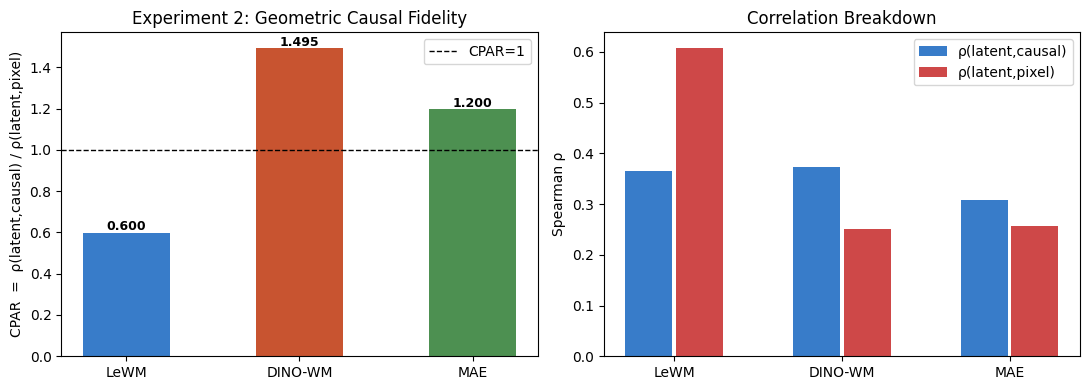

Figure saved to Drive.


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ["#1565C0", "#BF360C", "#2E7D32"][:len(results_df)]
ax = axes[0]
bars = ax.bar(results_df["model"], results_df["CPAR"], color=colors, alpha=0.85, width=0.5)
ax.axhline(1.0, color="black", linestyle="--", lw=1, label="CPAR=1")
ax.set_ylabel("CPAR  =  ρ(latent,causal) / ρ(latent,pixel)")
ax.set_title("Experiment 2: Geometric Causal Fidelity")
for bar, v in zip(bars, results_df["CPAR"]):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.3f}",
            ha="center", fontsize=9, fontweight="bold")
ax.legend()

ax = axes[1]
x = range(len(results_df))
ax.bar([i-0.15 for i in x], results_df["r_causal"], 0.28,
       label="ρ(latent,causal)", color="#1565C0", alpha=0.85)
ax.bar([i+0.15 for i in x], results_df["r_pixel"],  0.28,
       label="ρ(latent,pixel)",  color="#C62828", alpha=0.85)
ax.set_xticks(list(x)); ax.set_xticklabels(results_df["model"])
ax.set_ylabel("Spearman ρ"); ax.set_title("Correlation Breakdown"); ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "exp2_cpar.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved to Drive.")